In [3]:
import pandas as pd

# 데이터 불러오기
tr_cus_ar = pd.read_csv("data/cleaned_data.csv")

tr_cus_ar
tr_cus_ar.isna().sum()

Unnamed: 0                           0
t_dat                                0
customer_id                          0
article_id                           0
price                                0
sales_channel_id                     0
FN                              235644
Active                          235644
club_member_status              235644
age                             235644
age_group                       235644
product_code                         0
prod_name                            0
product_type_no                      0
product_type_name                    0
product_group_name                   0
graphical_appearance_no              0
graphical_appearance_name            0
colour_group_code                    0
colour_group_name                    0
perceived_colour_value_id            0
perceived_colour_value_name          0
perceived_colour_master_id           0
perceived_colour_master_name         0
department_no                        0
department_name          

In [5]:
total_sale = tr_cus_ar["price"].sum()
total_sale = total_sale.astype(int)
total_sale

np.int64(29128)

In [7]:
# 월별 상품군별 매출 groupby -> 제품군별 날짜에 따른 매출 pivot table 제작

mo_pro_pa = tr_cus_ar.groupby(["t_dat", "product_group_name"])["price"].sum()
mo_pro_pa = mo_pro_pa.to_frame()
pv_mpp = pd.pivot_table(mo_pro_pa,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66.513559,62.809288,62.980576,65.280390,68.408339,65.018576,67.019729,57.870831,69.094898,72.611932,86.277966,80.355966
Bags,0.133864,0.084695,0.313441,0.060983,0.203322,0.295441,0.589203,1.458864,1.435407,0.827017,1.249831,0.826627
Cosmetic,0.031576,0.024492,0.008458,NaN,NaN,0.013017,0.019458,0.005898,0.016458,0.021712,NaN,NaN
Furniture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007322,0.039915,0.118729,0.037254
Garment Full body,182.372695,209.080779,330.312813,524.765694,529.226983,648.162016,491.154254,287.544067,276.918169,259.187406,325.182457,279.086135
Garment Lower body,559.040745,563.925898,662.899118,743.382525,734.072134,825.248643,684.504677,556.516525,676.825610,578.168982,530.548339,461.605372
Garment Upper body,932.763574,823.499508,899.996473,839.574914,797.443015,799.213641,703.157287,710.808677,1274.635745,1203.619100,1237.101559,882.139117
Garment and Shoe care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028508,NaN,0.016932
Interior textile,0.008119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


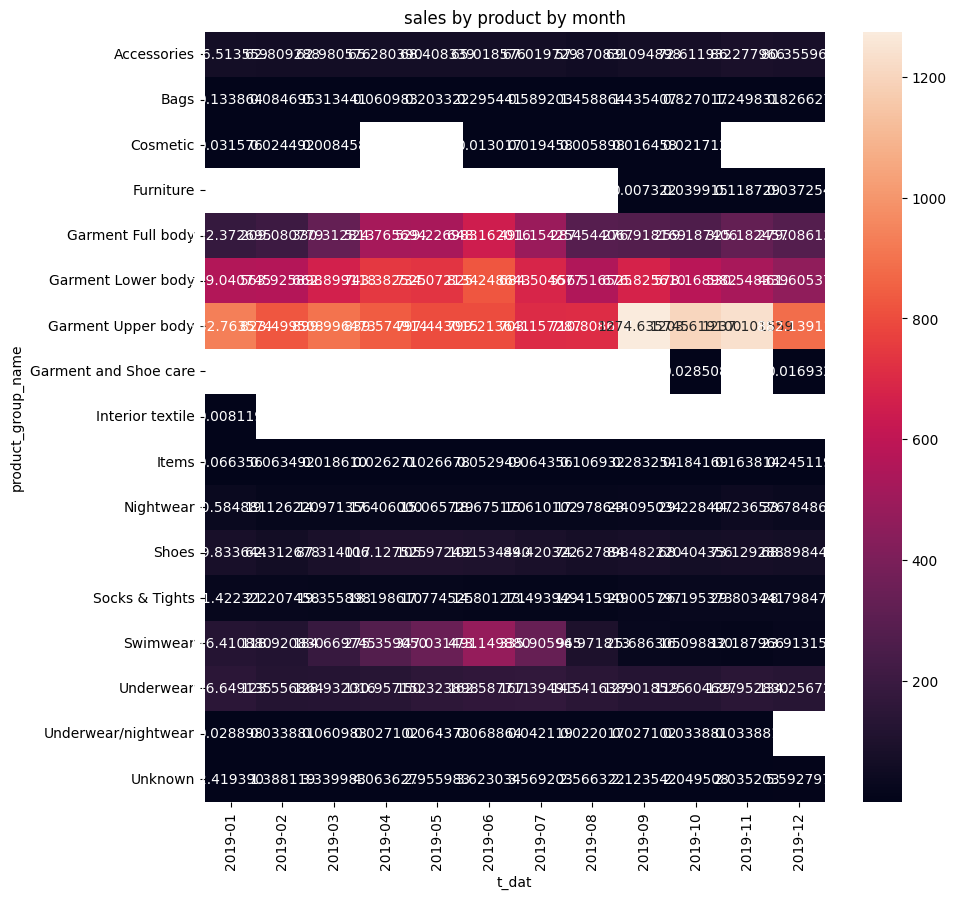

In [9]:
# 1차 히트맵 제작
# 결측치, price의 소숫점 문제로 보기 좋진 않음
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp, annot = True, fmt = "f")
plt.title("sales by product by month")
plt.show()

In [11]:
# 2차 히트맵 제작을 위한 mo_pro_pa의 복사본 제작
# 그 과정에서 인덱스가 되었던 product_group_name을 컬럼으로 다시 밀어냄
mpp_copy = mo_pro_pa.copy()
mpp_copy = mpp_copy.reset_index(drop = False)
mpp_copy = mpp_copy.set_index("t_dat")
mpp_copy

,product_group_name,price
t_dat,,
2019-01,Accessories,66.513559
2019-01,Bags,0.133864
2019-01,Cosmetic,0.031576
2019-01,Garment Full body,182.372695
2019-01,Garment Lower body,559.040745
...,...,...
2019-12,Shoes,68.898441
2019-12,Socks & Tights,28.798475
2019-12,Swimwear,23.913152


In [13]:
# 값이 다른 제품군과 비교해 너무 작은 것들을 '기타' 로 매핑
product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
mpp_copy.loc[mpp_copy["product_group_name"].isin(product_map), "product_group_name"] = "Others"

In [15]:
# 제품군별 월별 매출총합 피벗 테이블 제작
mpp_copy["price"] = mpp_copy["price"].round(2)
pv_mpp_copy = pd.pivot_table(mpp_copy,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp_copy

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66.51,62.81,62.98,65.28,68.41,65.02,67.02,57.87,69.09,72.61,86.28,80.36
Garment Full body,182.37,209.08,330.31,524.77,529.23,648.16,491.15,287.54,276.92,259.19,325.18,279.09
Garment Lower body,559.04,563.93,662.90,743.38,734.07,825.25,684.50,556.52,676.83,578.17,530.55,461.61
Garment Upper body,932.76,823.50,900.00,839.57,797.44,799.21,703.16,710.81,1274.64,1203.62,1237.10,882.14
Nightwear,30.58,19.13,14.97,17.41,15.07,18.68,15.61,17.98,23.10,29.23,44.24,33.78
Others,2.69,1.58,3.74,4.18,3.25,4.05,4.28,4.17,3.90,3.18,3.60,6.73
Shoes,79.83,62.31,87.31,106.13,105.97,102.53,89.42,74.63,84.48,68.40,73.13,68.90
Socks & Tights,21.42,21.21,19.36,18.20,17.77,14.80,13.49,12.42,20.01,26.20,29.80,28.80
Swimwear,126.41,118.92,184.67,275.36,347.03,473.15,335.91,94.97,25.69,16.10,12.19,23.91


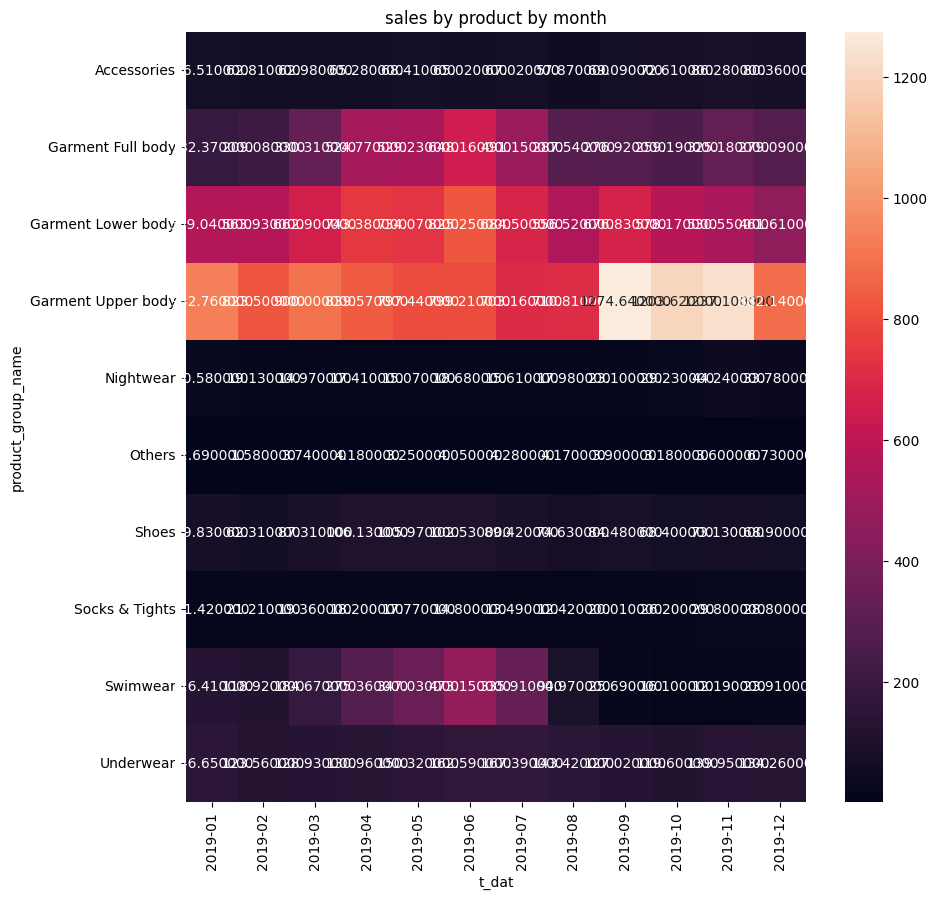

In [17]:
# 2차 히트맵 제작
# 자잘한 것들이 '기타' 로 묶이면서 결측치도 해결되고 이전보단 깔끔해짐
# 하지만 여전히 price의 소수값 이슈로 보기 힘듬
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp_copy, annot = True, fmt = "f")
plt.title("sales by product by month")
plt.show()

In [19]:
# 3차 히트맵 제작을 위한 기존 복사본을 다시 복사
mpp_copy2 = mpp_copy.copy()
mpp_copy2

,product_group_name,price
t_dat,,
2019-01,Accessories,66.51
2019-01,Others,0.13
2019-01,Others,0.03
2019-01,Garment Full body,182.37
2019-01,Garment Lower body,559.04
...,...,...
2019-12,Shoes,68.90
2019-12,Socks & Tights,28.80
2019-12,Swimwear,23.91


In [21]:
# price의 소수 이슈를 해결하기 위해 매출총합 값을 정수로 변환해 소숫점 이하 값 버림
mpp_copy2["price"] = mpp_copy2["price"].astype(int)

In [23]:
# price 정돈이 끝난 복사본도 이전처럼 피벗 테이블 제작
pv_mpp_copy2 = pd.pivot_table(mpp_copy2,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp_copy2

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66,62,62,65,68,65,67,57,69,72,86,80
Garment Full body,182,209,330,524,529,648,491,287,276,259,325,279
Garment Lower body,559,563,662,743,734,825,684,556,676,578,530,461
Garment Upper body,932,823,900,839,797,799,703,710,1274,1203,1237,882
Nightwear,30,19,14,17,15,18,15,17,23,29,44,33
Others,2,1,3,4,2,3,3,3,3,2,3,5
Shoes,79,62,87,106,105,102,89,74,84,68,73,68
Socks & Tights,21,21,19,18,17,14,13,12,20,26,29,28
Swimwear,126,118,184,275,347,473,335,94,25,16,12,23


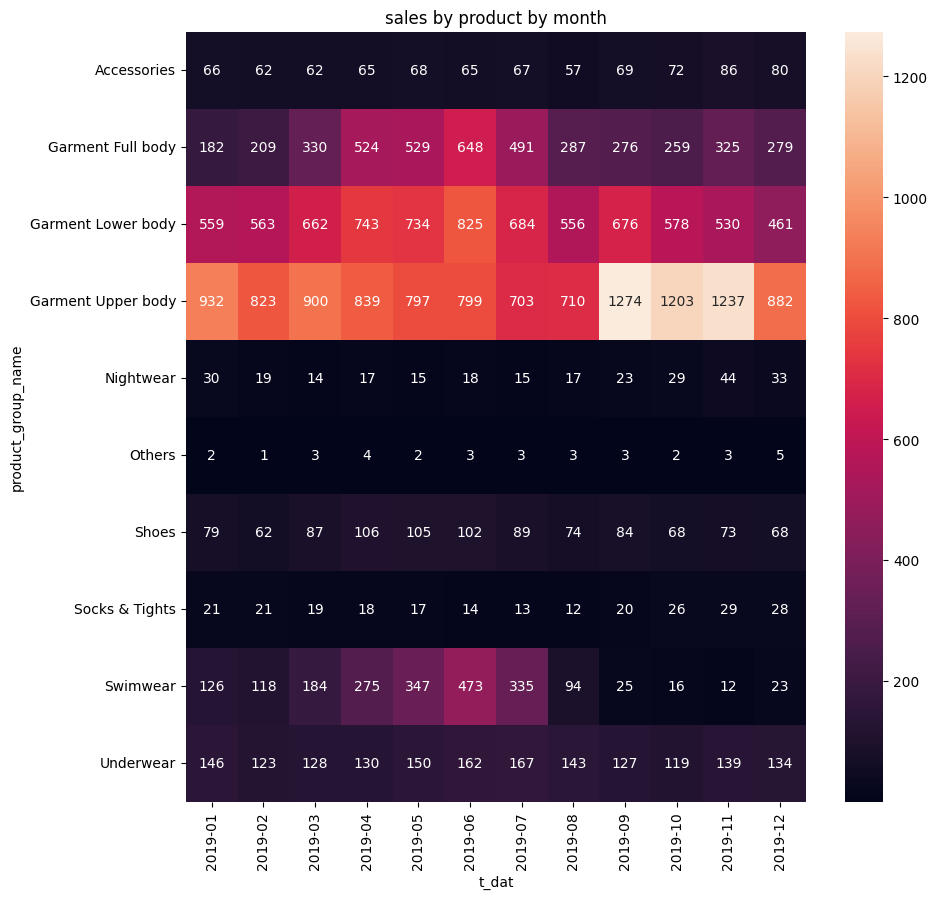

In [25]:
# 최종 3차 히트맵 제작
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp_copy2, annot = True, fmt = "d")
plt.title("sales by product by month")
plt.show()

In [27]:
# 수치가 큰 전신, 상의 하의 옷 때문에 다른 제품군의 차이가 보이지 않는 문제로 두 그룹을 분리
mpp_copy3 = mpp_copy2.copy()
group_map =["Garment Full body", "Garment Lower body", "Garment Upper body"] 
mpp_garment = mpp_copy3[mpp_copy3["product_group_name"].isin(group_map)]
mpp_others = mpp_copy3[~mpp_copy3["product_group_name"].isin(group_map)]
mpp_others

,product_group_name,price
t_dat,,
2019-01,Accessories,66
2019-01,Others,0
2019-01,Others,0
2019-01,Others,0
2019-01,Others,0
...,...,...
2019-12,Shoes,68
2019-12,Socks & Tights,28
2019-12,Swimwear,23


In [29]:
# 두 개로 나눈 그룹을 각각 pivot table로
pv_garment = pd.pivot_table(mpp_garment,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_others = pd.pivot_table(mpp_others,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")

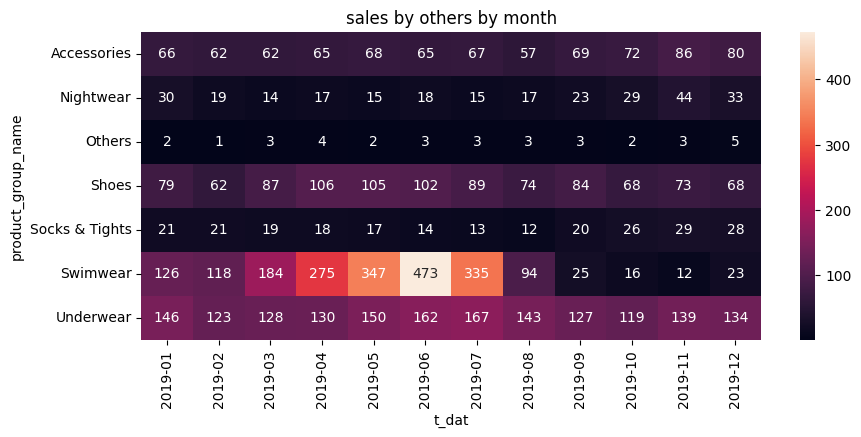

In [31]:
# 수치가 작았던 그룹의 히트맵
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 4))
sale_heat = sns.heatmap(pv_others, annot = True, fmt = "d")
plt.title("sales by others by month")
plt.show()

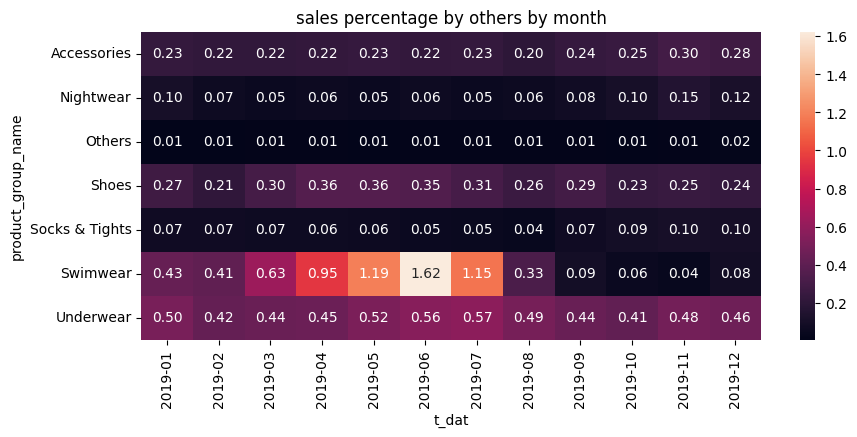

In [33]:
# 수치가 작았던 그룹의 히트맵(총매출에 대한 비율 버전)
# 매출만 가지고 그렸을 때와 별 다른 차이가 보이지 않아, 비율을 가지고 더 그릴 필요는 없어보임.
import matplotlib.pyplot as plt
import seaborn as sns

pv_others_per = mpp_copy.copy()
group_map =["Garment Full body", "Garment Lower body", "Garment Upper body"] 
pv_others_per = pv_others_per[~pv_others_per["product_group_name"].isin(group_map)]
pv_others_per["price_per"] = (pv_others_per["price"] / total_sale * 100)
pv_others_per = pd.pivot_table(pv_others_per,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price_per",
                        aggfunc = "sum")

plt.figure(figsize = (10, 4))
sale_heat = sns.heatmap(pv_others_per, annot = True, fmt = ".2f")
plt.title("sales percentage by others by month")
plt.show()

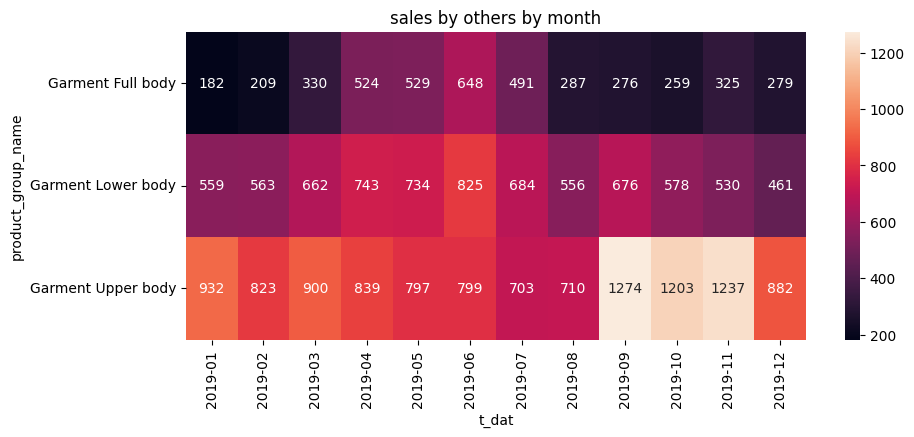

In [35]:
# 수치가 컸던 그룹의 히트맵
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 4))
sale_heat = sns.heatmap(pv_garment, annot = True, fmt = "d")
plt.title("sales by others by month")
plt.show()

In [37]:
 #나이대별 제품군별 매출
# 나이대별 제품군별 groupby로 매출 총합 -> 제품군의 '기타' 매핑 -> 피벗 테이블 제작
age_pro_sa = tr_cus_ar.groupby(["age_group", "product_group_name"])["price"].sum().reset_index(drop = False)
age_pro_sa["price"] = age_pro_sa["price"].astype(int)

product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
age_pro_sa.loc[age_pro_sa["product_group_name"].isin(product_map), "product_group_name"] = "Others"

pv_aps = pd.pivot_table(age_pro_sa,
                        index = "product_group_name",
                        columns = "age_group",
                        values = "price",
                        aggfunc = "sum")
pv_aps

age_group,20대,30대,40대,50대,60대,70대+
product_group_name,,,,,,
Accessories,299,132,85,92,24,5
Garment Full body,1345,729,526,597,145,24
Garment Lower body,2346,1191,974,1061,248,46
Garment Upper body,3437,1706,1322,1606,436,92
Nightwear,84,48,36,37,9,1
Others,14,6,4,4,1,0
Shoes,310,195,114,121,34,5
Socks & Tights,73,43,31,31,6,0
Swimwear,802,302,201,235,35,3


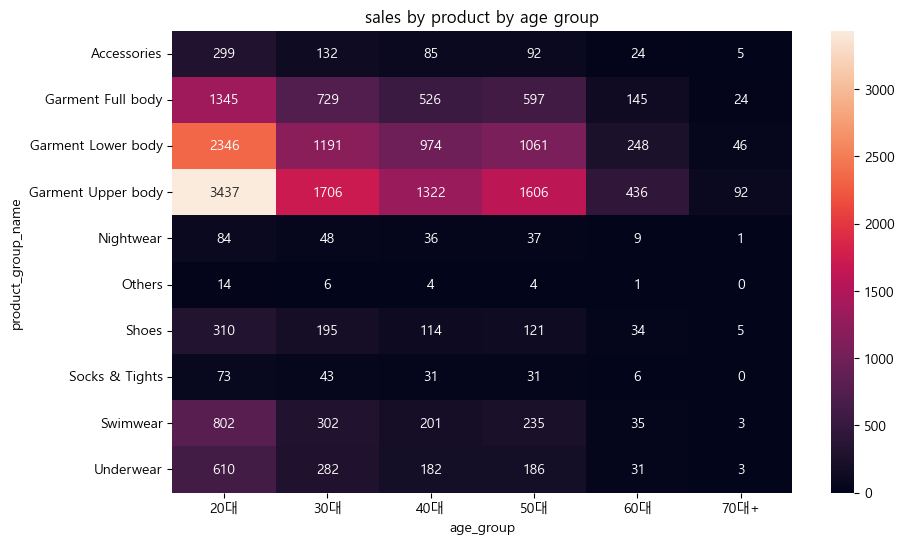

In [39]:
# 나이대별 제품군별 매출 총합 히트맵 제작
# 나이대에 한글이 들어가있어 한글 폰트 불러옴
# 이외엔 월별 제품군별 매출 총합 구할때와 동일
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break

plt.figure(figsize = (10, 6))
sale_heat = sns.heatmap(pv_aps, annot = True, fmt = "d")
plt.title("sales by product by age group")
plt.show()

<Figure size 1000x1000 with 0 Axes>

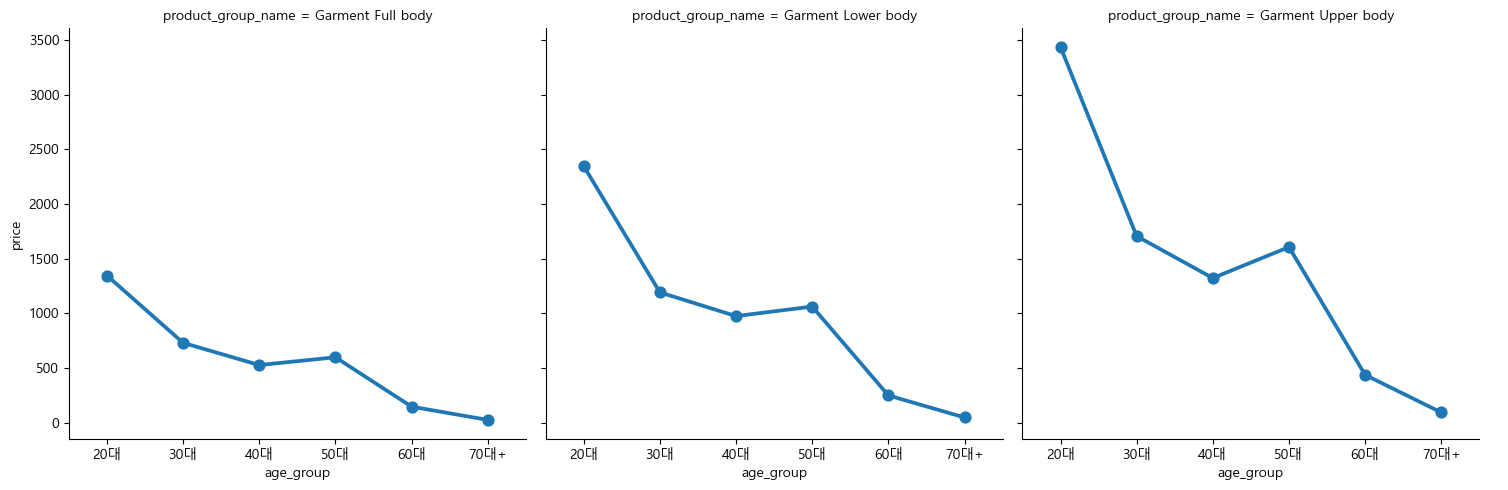

In [41]:
# 각 제품군의 나이대별 매출 차이를 더 명확하게 확인하기 위한 선 그래프
# 우선 최상위 매출을 보인 상위 3개의 제품군 
age_garment = age_pro_sa.copy()
age_garment = age_garment[age_garment["product_group_name"].isin(group_map)]

plt.figure(figsize = (10, 10))
sns.catplot(x = age_garment["age_group"], 
            y = age_garment["price"], 
            col = age_garment["product_group_name"], 
            data = age_garment, 
            kind = "point")
plt.show()

<Figure size 1000x1000 with 0 Axes>

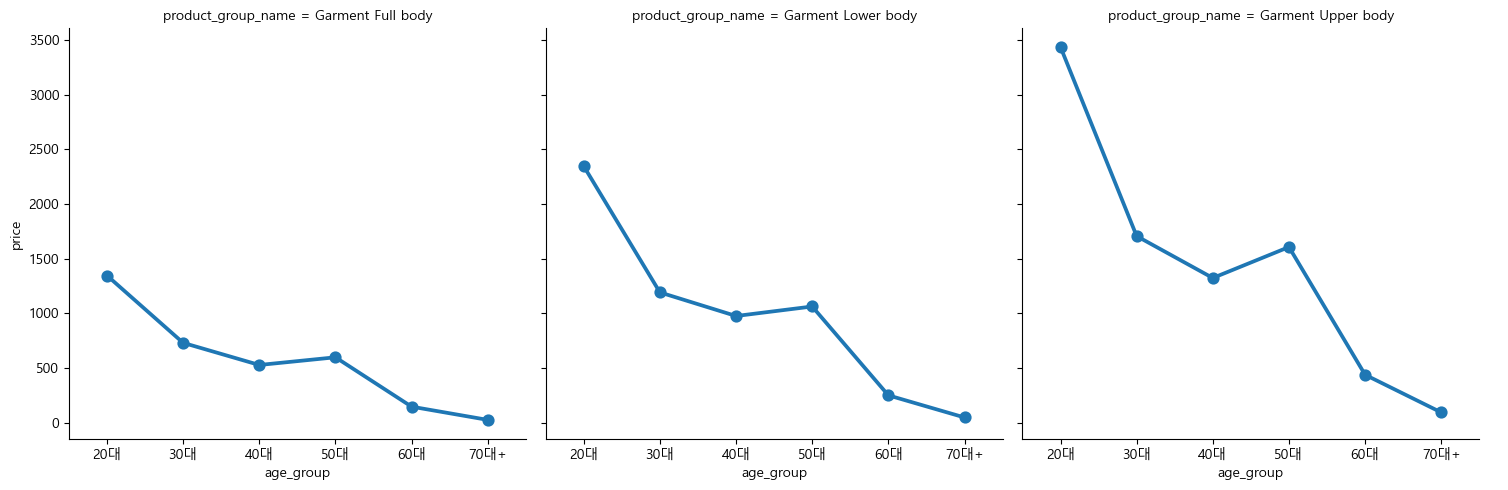

In [42]:
# 확실한 차이를 보기 위해 가격을 정수 변환(버림) 대신 소수 두 자리수로 반올림
# 그럼에도 정수로 변환했을 때와 차이는 없음
age_garment_f = tr_cus_ar.groupby(["age_group", "product_group_name"])["price"].sum().reset_index(drop = False)
age_garment_f["price"] = age_garment_f["price"].round(2)
age_garment_f = age_garment_f[age_garment_f["product_group_name"].isin(group_map)]

plt.figure(figsize = (10, 10))
sns.catplot(x = age_garment_f["age_group"], 
            y = age_garment_f["price"], 
            col = age_garment_f["product_group_name"], 
            data = age_garment_f, 
            kind = "point")
plt.show()

<Figure size 1000x1000 with 0 Axes>

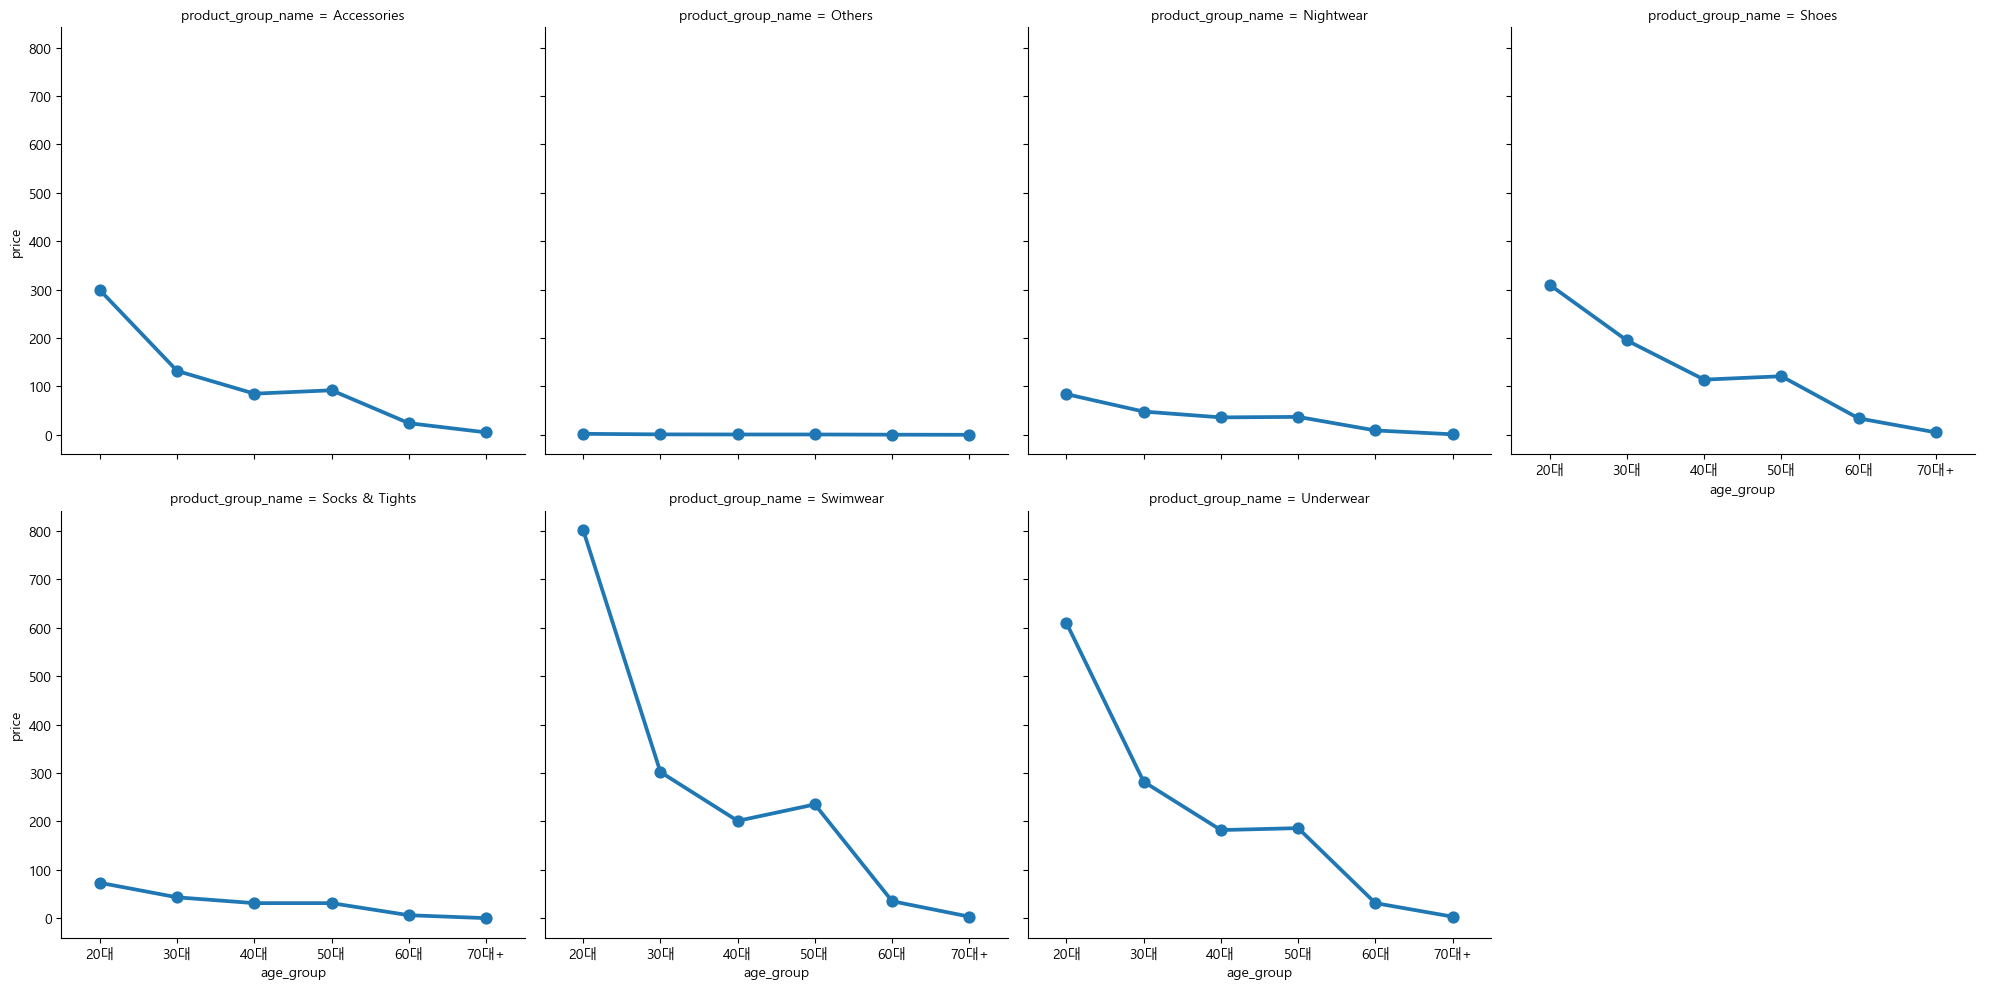

In [43]:
# 가장 잘 팔린 제품군 3개를 제외한 나머지 제품군의 나이대별 매출 차이를 나타낸 선 그래프
age_others = age_pro_sa.copy()
age_others = age_others[~age_others["product_group_name"].isin(group_map)]

plt.figure(figsize = (10, 10))
sns.catplot(x = age_others["age_group"], 
            y = age_others["price"], 
            col = age_others["product_group_name"], 
            col_wrap= 4,
            data = age_others, 
            kind = "point")
plt.show()

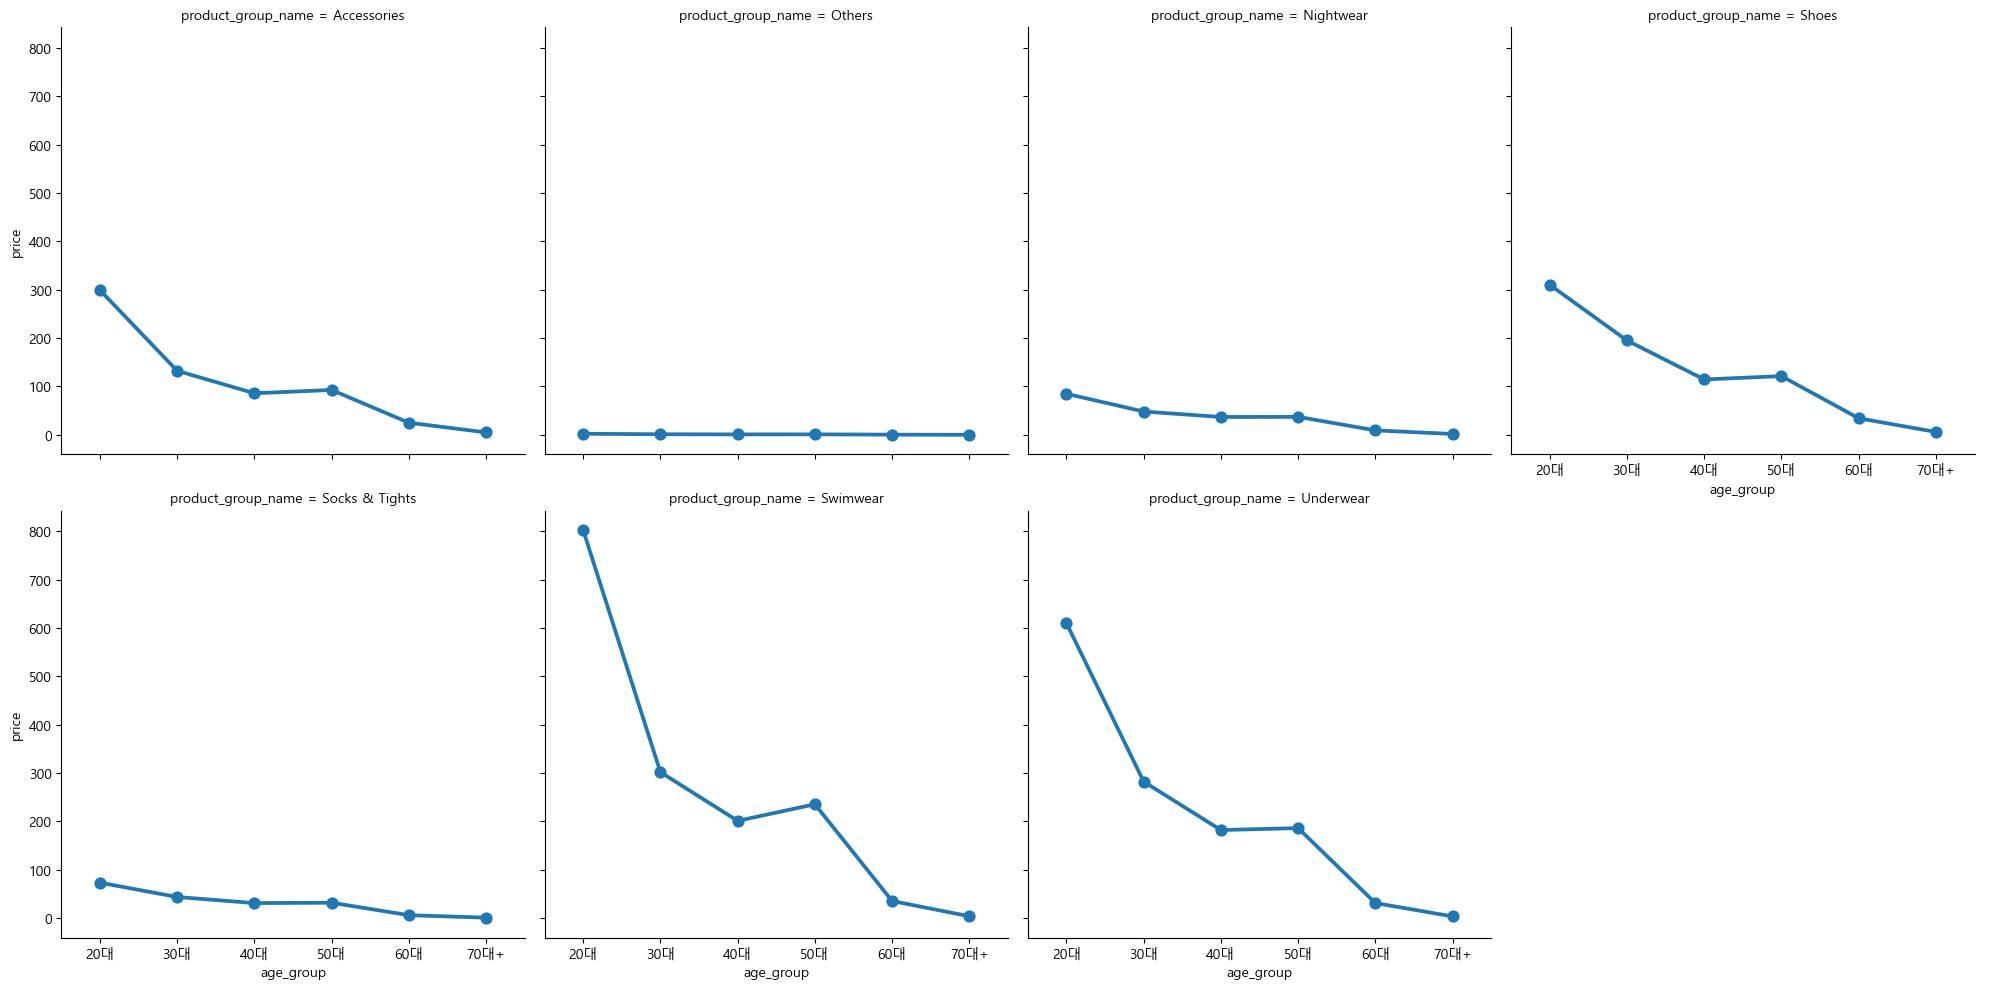

In [44]:
# 하위 제품군의 나이대별 차이를 나타낸 선그래프
# 이번에도 정확한 차이를 보기위해 반올림을 써봤지만 차이가 없음
age_others_f = tr_cus_ar.groupby(["age_group", "product_group_name"])["price"].sum().reset_index(drop = False)
age_others_f["price"] = age_others_f["price"].round(2)
age_others_f = age_others_f[~age_others_f["product_group_name"].isin(group_map)]

product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
age_others_f.loc[age_others_f["product_group_name"].isin(product_map), "product_group_name"] = "Others"

sns.catplot(x = age_others_f["age_group"], 
            y = age_others_f["price"], 
            col = age_others_f["product_group_name"], 
            col_wrap= 4,
            data = age_others_f, 
            kind = "point")
plt.show()

<Figure size 1500x1500 with 0 Axes>

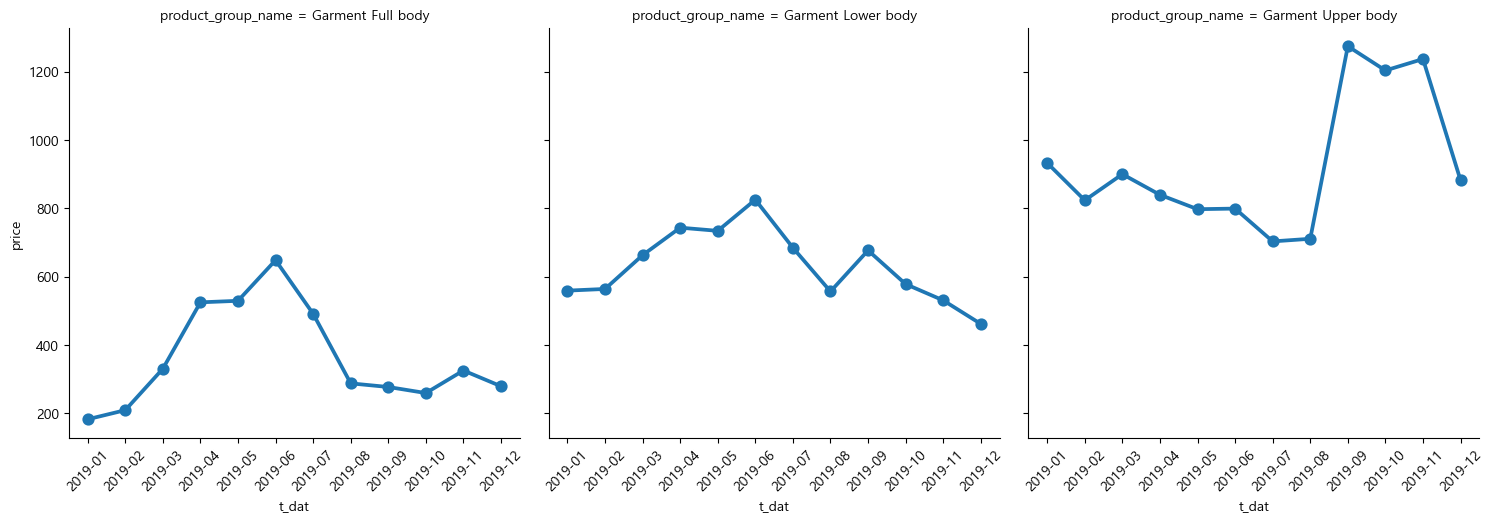

In [46]:
# 이번엔 상위 3개 제품군의 월별 매출 차이를 나타낸 선 그래프
mo_pro_pa_copy = mo_pro_pa.copy()
mo_pro_pa_copy = mo_pro_pa_copy.reset_index(drop = False)

product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
mo_pro_pa_copy.loc[mo_pro_pa_copy["product_group_name"].isin(product_map), "product_group_name"] = "Others"

mo_garment = mo_pro_pa_copy.copy()
mo_garment = mo_garment[mo_garment["product_group_name"].isin(group_map)]

plt.figure(figsize = (15, 15))
mo_plot = sns.catplot(x = mo_garment["t_dat"], 
            y = mo_garment["price"], 
            col = mo_garment["product_group_name"], 
            data = mo_garment, 
            kind = "point")
mo_plot.tick_params(axis = "x", rotation = 45)
plt.show()

<Figure size 1500x1500 with 0 Axes>

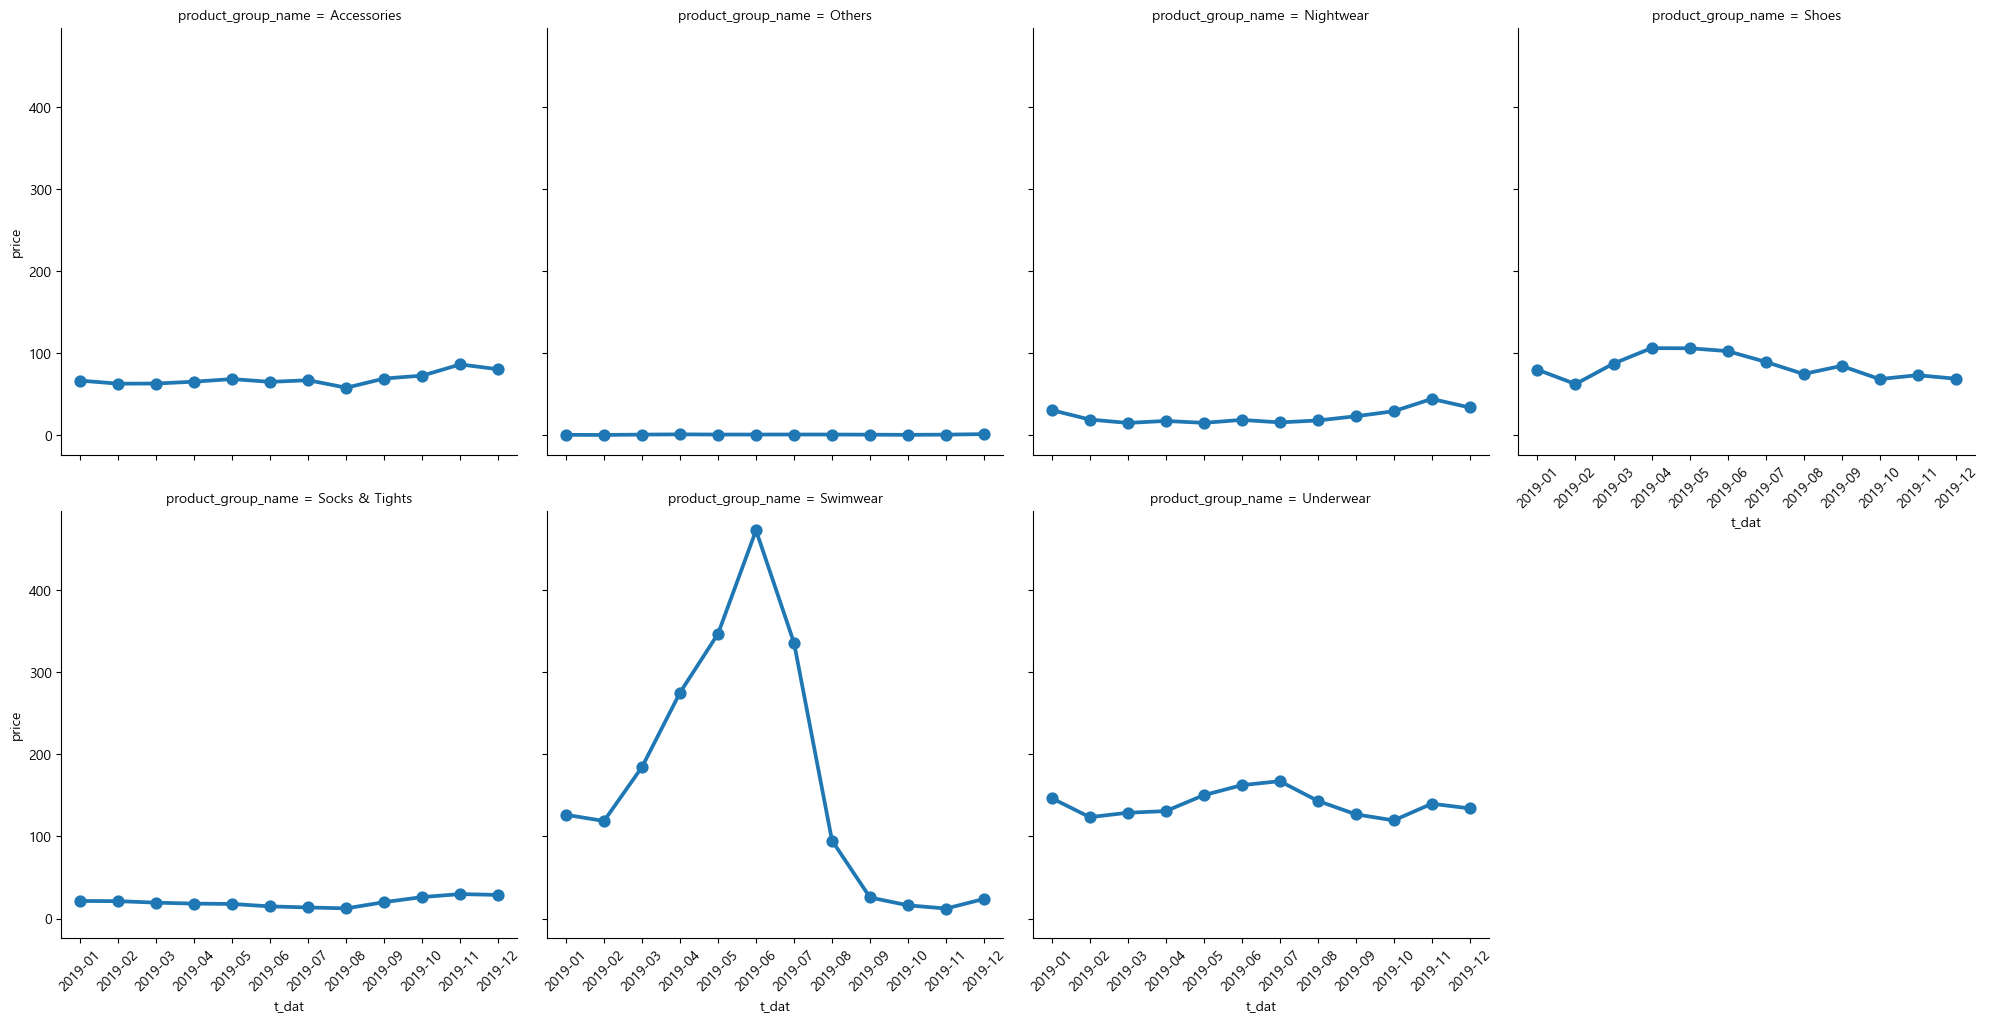

In [47]:
# 하위 제품군들의 월별 매출 차이를 볼 수 있는 선 그래프
mo_others = mo_pro_pa_copy.copy()
mo_others = mo_others[~mo_others["product_group_name"].isin(group_map)]

plt.figure(figsize = (15, 15))
mo_plot = sns.catplot(x = mo_others["t_dat"], 
            y = mo_others["price"], 
            col = mo_others["product_group_name"], 
            col_wrap = 4,
            data = mo_others, 
            kind = "point")
mo_plot.tick_params(axis = "x", rotation = 45)
plt.show()

In [49]:
# 혹시 모를 검증용으로 각 제품군 별 판매 빈도수? 를 보기 위한 product_qty 생성 
product_qty = tr_cus_ar.groupby("product_group_name")["article_id"].count().reset_index(drop = False)
product_qty.loc[product_qty["product_group_name"].isin(product_map), "product_group_name"] = "Others"
product_qty = product_qty.groupby("product_group_name")["article_id"].sum().reset_index(drop = False)
product_qty

,product_group_name,article_id
0,Accessories,52220
1,Garment Full body,117701
2,Garment Lower body,232472
3,Garment Upper body,415881
4,Nightwear,11283
5,Others,1888
6,Shoes,25554
7,Socks & Tights,21267
8,Swimwear,89657
9,Underwear,80652


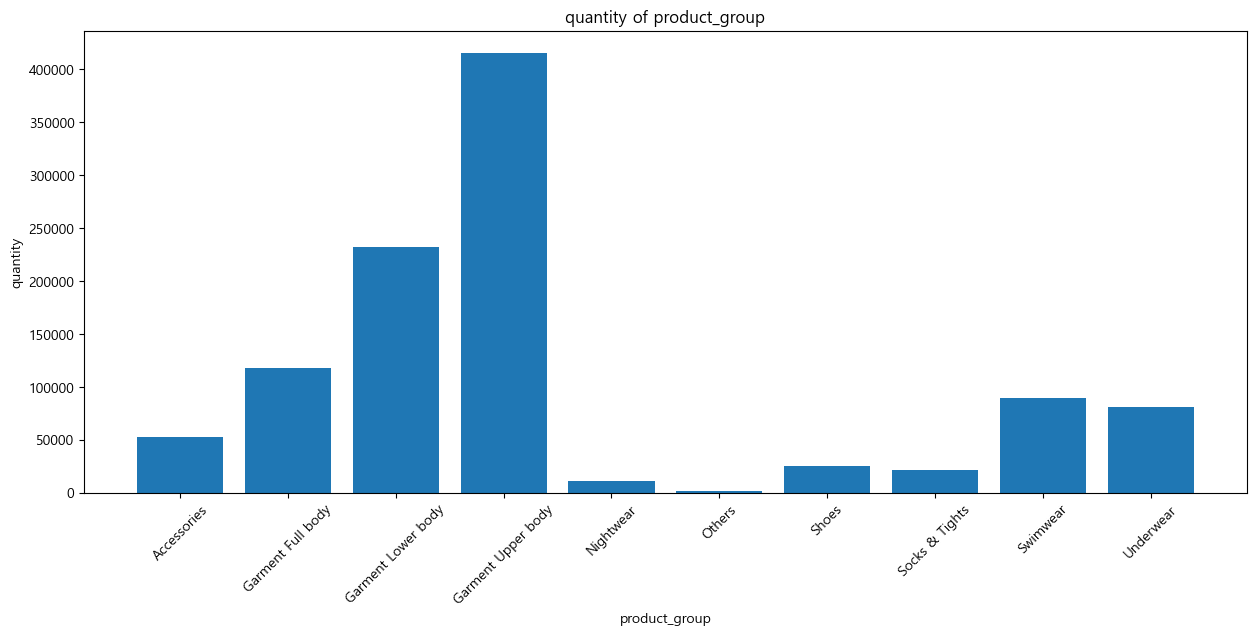

In [50]:
# 위 표의 차이를 보기 위해 막대 그래프 생성
import matplotlib.pyplot as plt

plt.figure(figsize = (15, 6))
plt.bar(product_qty["product_group_name"], product_qty["article_id"])
plt.xlabel("product_group")
plt.ylabel("quantity")
plt.xticks(rotation = 45)
plt.title("quantity of product_group")
plt.show()

In [52]:
# 각 제품군별 총매출도 확인
product_sale = tr_cus_ar.groupby("product_group_name")["price"].sum().reset_index(drop = False)
product_sale["price"] = product_sale["price"].astype(int)
product_sale.loc[product_sale["product_group_name"].isin(product_map), "product_group_name"] = "Others"
product_sale = product_sale.groupby("product_group_name")["price"].sum().reset_index(drop = False)
product_sale

,product_group_name,price
0,Accessories,824
1,Garment Full body,4342
2,Garment Lower body,7576
3,Garment Upper body,11103
4,Nightwear,279
5,Others,43
6,Shoes,1003
7,Socks & Tights,243
8,Swimwear,2034
9,Underwear,1674


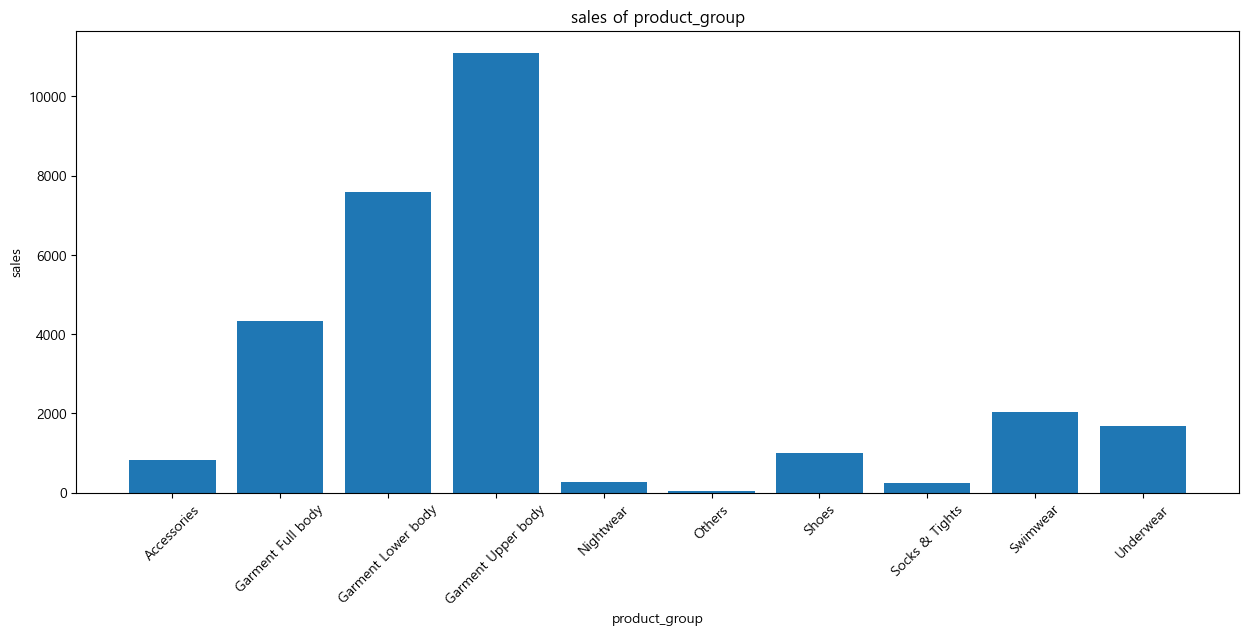

In [54]:
# 제품군별 총매출 차이를 확인하기 위한 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize = (15, 6))
plt.bar(product_sale["product_group_name"], product_sale["price"])
plt.xlabel("product_group")
plt.ylabel("sales")
plt.xticks(rotation = 45)
plt.title("sales of product_group")
plt.show()

In [57]:
# 30대와 50대의 데이터만을 저장한 age_30과 age_50 생성
age_30 = tr_cus_ar[tr_cus_ar["age_group"] == "30대"]
age_50 = tr_cus_ar[tr_cus_ar["age_group"] == "50대"]

In [59]:
# 30대와 50대의 총 매출과 총 구매수

age_30_total = age_30["price"].sum()
age_50_total = age_50["price"].sum()
age_30_count = age_30["article_id"].count()
age_50_count = age_50["article_id"].count()

print(f"총 매출 비교: 30대({age_30_total})가 50대({age_50_total})의 약 {age_30_total / age_50_total: .1f}배")
print(f"총 구매수 비교: 30대({age_30_count})가 50대({age_50_count})의 약 {age_30_count / age_50_count: .1f}배")

총 매출 비교: 30대(4638.455534656)가 50대(3975.9158583179997)의 약  1.2배
총 구매수 비교: 30대(165831)가 50대(136290)의 약  1.2배


In [61]:
# 30대의 제품 중분류별 매출 확인을 위한 groupby + 아이용 제품(Children) 매핑, 길이가 긴 이름 조정
age_30_index = age_30.groupby("index_name")["price"].sum().reset_index(drop = False)
child_map = ["Children Sizes 134-170", "Children Sizes 92-140"]
age_30_index.loc[age_30_index["index_name"].isin(child_map), "index_name"] = "Children"
age_30_index.loc[age_30_index["index_name"] == "Baby Sizes 50-98", "index_name"] = "Baby"
age_30_index.loc[age_30_index["index_name"] == "Children Accessories, Swimwear", "index_name"] = "Children\nAccessories,\nSwimwear"
age_30_index["index_name"].value_counts()

index_name
Children                            2
Baby                                1
Children\nAccessories,\nSwimwear    1
Divided                             1
Ladies Accessories                  1
Ladieswear                          1
Lingeries/Tights                    1
Menswear                            1
Sport                               1
Name: count, dtype: int64

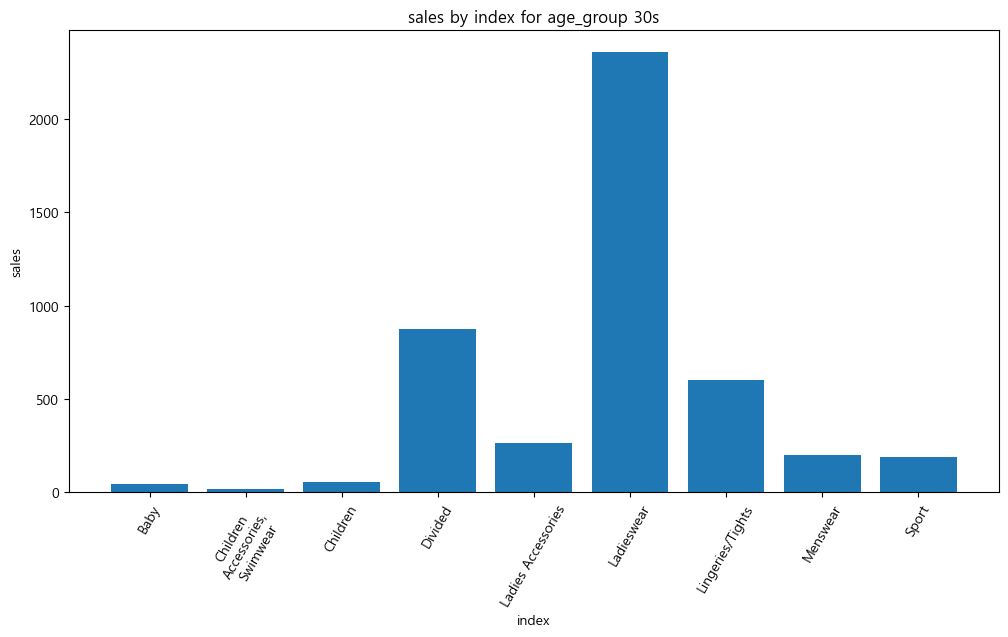

In [63]:
# 30대의 중분류별 매출 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
plt.bar(age_30_index["index_name"], age_30_index["price"])
plt.xlabel("index")
plt.ylabel("sales")
plt.xticks(rotation = 60)
plt.title("sales by index for age_group 30s")
plt.show()

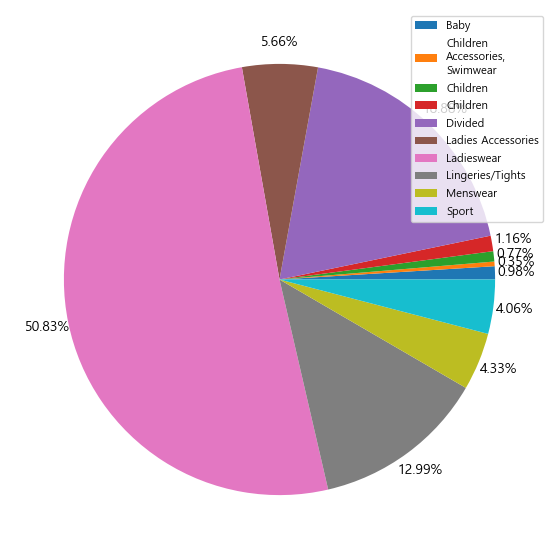

In [65]:
import matplotlib.pyplot as plt

age_30_index["sales_size"] = (age_30_index["price"] / age_30_total * 100)

plt.figure(figsize=(7,7))
plt.pie(age_30_index["sales_size"], autopct = "%.2f%%", pctdistance = 1.1)
plt.legend(age_30_index["index_name"], fontsize = 8)
plt.show()

In [67]:
# 50대의 제품 중분류별 매출 확인을 위한 groupby + 아이용 제품(Children) 매핑, 길이가 긴 이름 조정
age_50_index = age_50.groupby("index_name")["price"].sum().reset_index(drop = False)
child_map = ["Children Sizes 134-170", "Children Sizes 92-140"]
age_50_index.loc[age_50_index["index_name"].isin(child_map), "index_name"] = "Children"
age_50_index.loc[age_50_index["index_name"] == "Baby Sizes 50-98", "index_name"] = "Baby"
age_50_index.loc[age_50_index["index_name"] == "Children Accessories, Swimwear", "index_name"] = "Children\nAccessories,\nSwimwear"
age_50_index["index_name"].value_counts()

index_name
Children                            2
Baby                                1
Children\nAccessories,\nSwimwear    1
Divided                             1
Ladies Accessories                  1
Ladieswear                          1
Lingeries/Tights                    1
Menswear                            1
Sport                               1
Name: count, dtype: int64

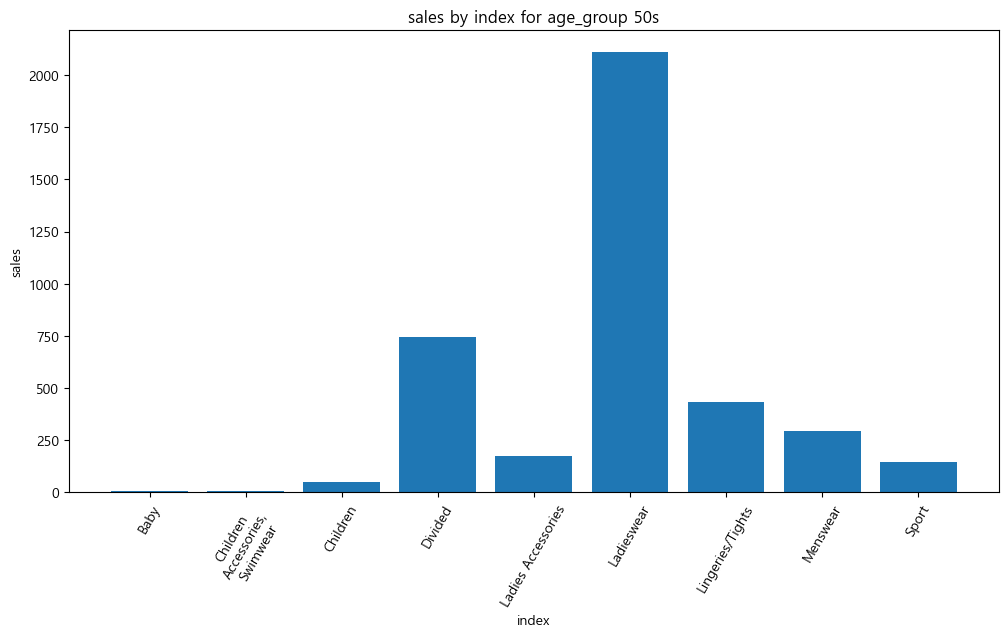

In [69]:
# 50대의 중분류별 매출 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
plt.bar(age_50_index["index_name"], age_50_index["price"])
plt.xlabel("index")
plt.ylabel("sales")
plt.xticks(rotation = 60)
plt.title("sales by index for age_group 50s")
plt.show()

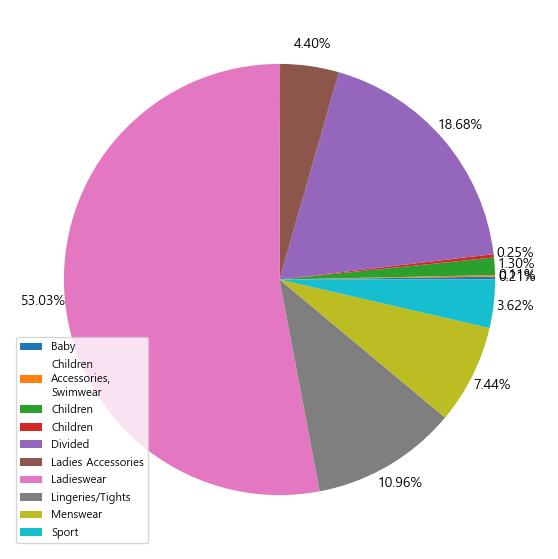

In [71]:
import matplotlib.pyplot as plt

age_50_index["sales_size"] = (age_50_index["price"] / age_50_total * 100)

plt.figure(figsize=(7,7))
plt.pie(age_50_index["sales_size"], autopct = "%.2f%%", pctdistance = 1.1)
plt.legend(age_50_index["index_name"], fontsize = 8)
plt.show()

In [73]:
# 30대의 소분류별 매출
# 소분류 종류가 워낙 많아서 매출 상위만 봐야 할 듯
age_30_depart = age_30.groupby("department_name")["price"].sum().reset_index(drop = False)
age_30_depart = age_30_depart.sort_values("price", ascending = False)
age_30_depart.head()

,department_name,price
113,Knitwear,286.464644
193,Trouser,282.433780
180,Swimwear,282.042999
75,Jersey,279.807745
50,Dress,253.380796


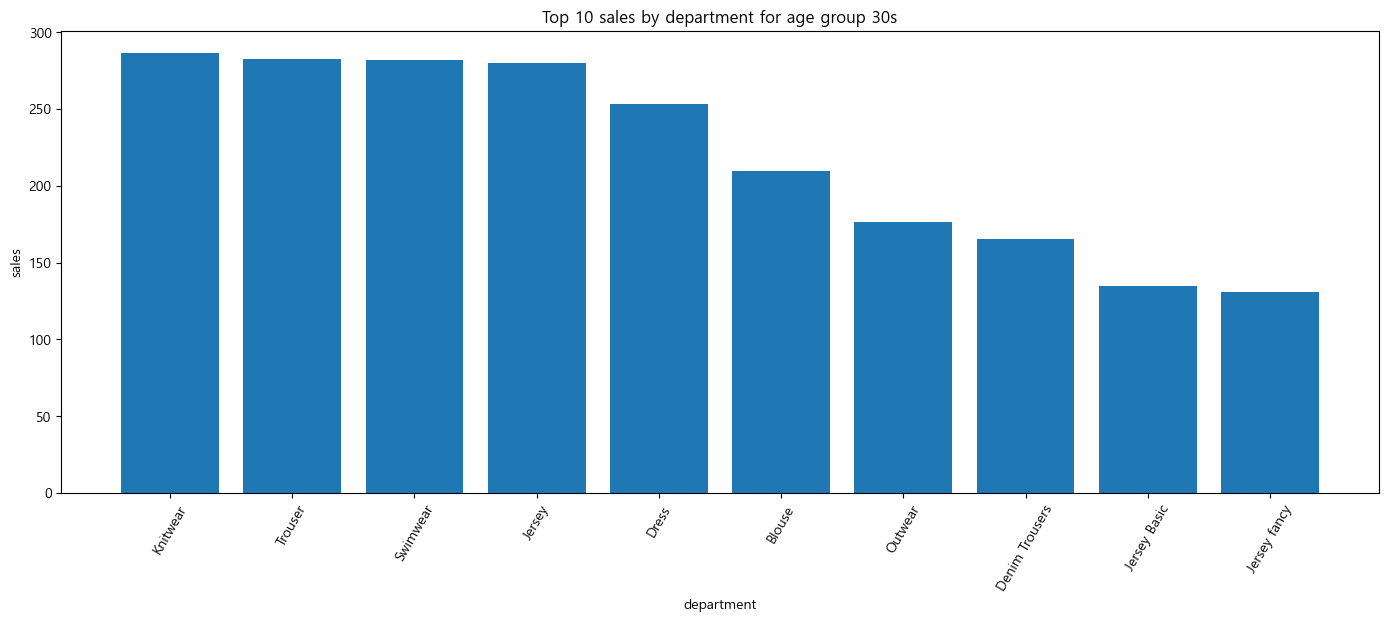

In [75]:
# 30대의 소분류별 매출 Top 30 막대 그래프
import matplotlib.pyplot as plt

age_30_depart_top10 = age_30_depart.iloc[0:10]

plt.figure(figsize = (17, 6))
plt.bar(age_30_depart_top10["department_name"], age_30_depart_top10["price"])
plt.xlabel("department")
plt.ylabel("sales")
plt.xticks(rotation = 60)
plt.title("Top 10 sales by department for age group 30s")
plt.show()

In [77]:
import matplotlib.pyplot as plt

age_30_depart_top5_list = age_30_depart[0:5]
age_30_depart_top5_list = age_30_depart_top5_list["department_name"].to_list()
age_30_depart_top5_list

age_30_depart_top5 = age_30_depart.copy()
age_30_depart_top5.loc[~age_30_depart_top5["department_name"].isin(age_30_depart_top5_list), "department_name"] = "Others"
age_30_depart_top5 = age_30_depart_top5

In [80]:
# 50대의 소분류별 매출
# 소분류 종류가 워낙 많아서 매출 상위만 봐야 할 듯
age_50_depart = age_50.groupby("department_name")["price"].sum().reset_index(drop = False)
age_50_depart = age_50_depart.sort_values("price", ascending = False)
age_50_depart.head()

,department_name,price
193,Trouser,328.956220
113,Knitwear,297.501406
50,Dress,246.158033
29,Blouse,232.222204
180,Swimwear,225.769304


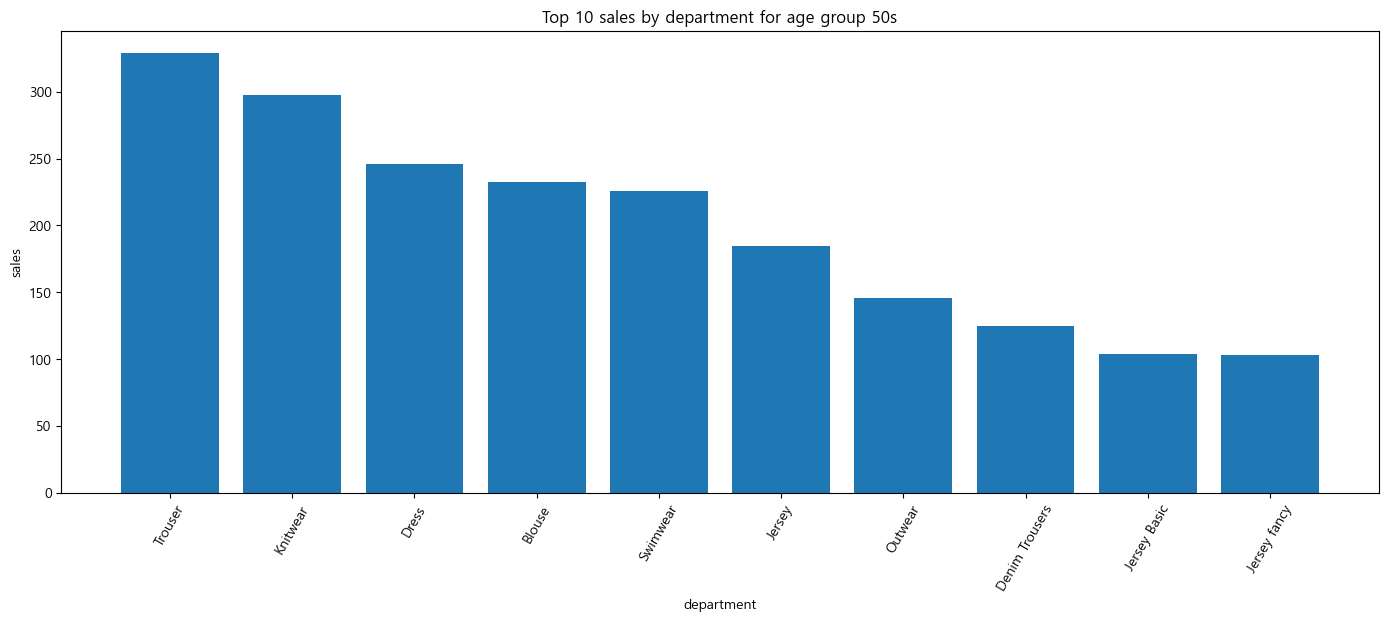

In [82]:
# 50대의 소분류별 매출 Top 30 막대 그래프
import matplotlib.pyplot as plt

age_50_depart_top10 = age_50_depart.iloc[0:10]

plt.figure(figsize = (17, 6))
plt.bar(age_50_depart_top10["department_name"], age_50_depart_top10["price"])
plt.xlabel("department")
plt.ylabel("sales")
plt.xticks(rotation = 60)
plt.title("Top 10 sales by department for age group 50s")
plt.show()

In [84]:
age_30_depart_top10.head(10)

,department_name,price
113,Knitwear,286.464644
193,Trouser,282.433780
180,Swimwear,282.042999
75,Jersey,279.807745
50,Dress,253.380796
29,Blouse,209.447542
140,Outwear,176.319983
42,Denim Trousers,165.143847
76,Jersey Basic,134.945677
81,Jersey fancy,130.800135


In [86]:
age_50_depart_top10.head(10)

,department_name,price
193,Trouser,328.956220
113,Knitwear,297.501406
50,Dress,246.158033
29,Blouse,232.222204
180,Swimwear,225.769304
75,Jersey,184.975983
140,Outwear,145.968983
42,Denim Trousers,124.622305
76,Jersey Basic,103.588186
81,Jersey fancy,103.420373


In [88]:
# 30대의 소분류별 구매수
# 소분류 종류가 워낙 많아서 상위만 봐야 할 듯
age_30_depart_cnt = age_30.groupby("department_name")["article_id"].count().reset_index(drop = False)
age_30_depart_cnt = age_30_depart_cnt.sort_values("article_id", ascending = False)
age_30_depart_cnt = age_30_depart_cnt.rename(columns = {"article_id" : "article_cnt"})
age_30_depart_cnt = age_30_depart_cnt[0:10]

In [90]:
# 50대의 소분류별 구매수
# 소분류 종류가 워낙 많아서 상위만 봐야 할 듯
age_50_depart_cnt = age_50.groupby("department_name")["article_id"].count().reset_index(drop = False)
age_50_depart_cnt = age_50_depart_cnt.sort_values("article_id", ascending = False)
age_50_depart_cnt = age_50_depart_cnt.rename(columns = {"article_id" : "article_cnt"})
age_50_depart_cnt = age_50_depart_cnt[0:10]

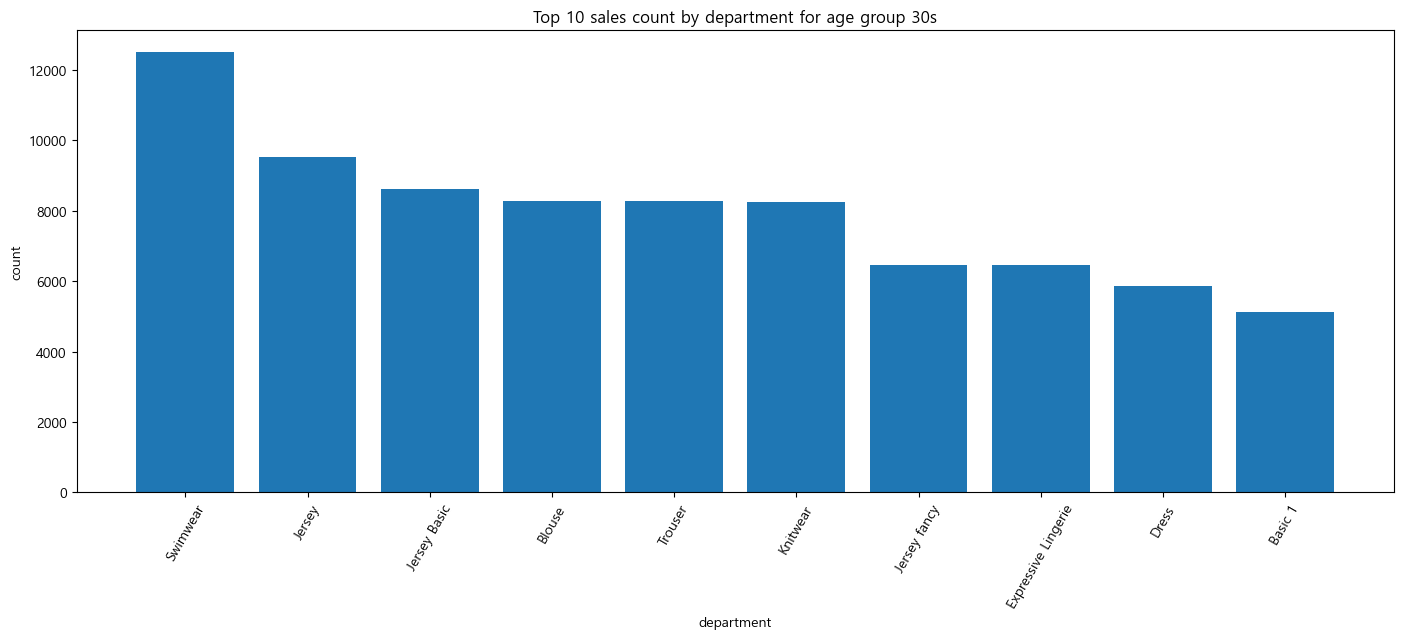

In [92]:
# 30대의 소분류별 구매수 Top 10 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize = (17, 6))
plt.bar(age_30_depart_cnt["department_name"], age_30_depart_cnt["article_cnt"])
plt.xlabel("department")
plt.ylabel("count")
plt.xticks(rotation = 60)
plt.title("Top 10 sales count by department for age group 30s")
plt.show()

In [94]:
age_30_depart_cnt.head(10)

,department_name,article_cnt
180,Swimwear,12499
75,Jersey,9526
76,Jersey Basic,8625
29,Blouse,8285
193,Trouser,8270
113,Knitwear,8243
81,Jersey fancy,6460
60,Expressive Lingerie,6447
50,Dress,5854
24,Basic 1,5127


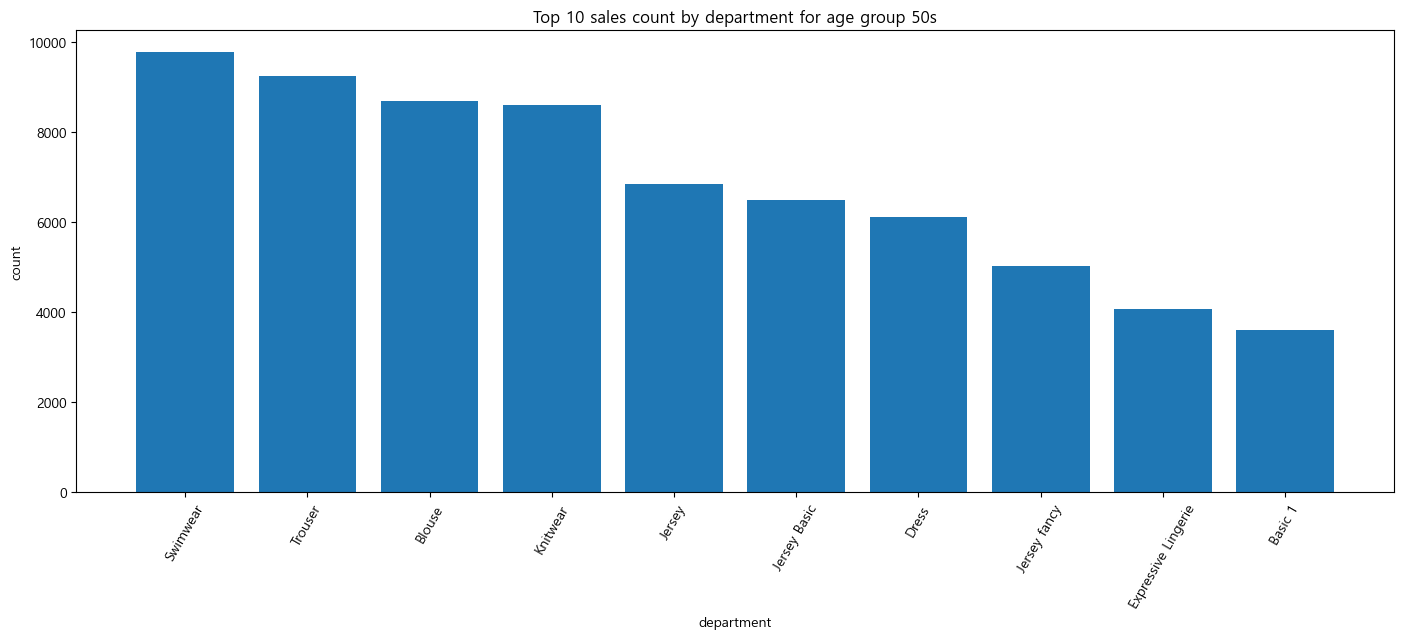

In [96]:
# 50대의 소분류별 구매수 Top 30 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize = (17, 6))
plt.bar(age_50_depart_cnt["department_name"], age_50_depart_cnt["article_cnt"])
plt.xlabel("department")
plt.ylabel("count")
plt.xticks(rotation = 60)
plt.title("Top 10 sales count by department for age group 50s")
plt.show()

In [98]:
age_50_depart_cnt.head(10)

,department_name,article_cnt
180,Swimwear,9765
193,Trouser,9242
29,Blouse,8686
113,Knitwear,8593
75,Jersey,6842
76,Jersey Basic,6484
50,Dress,6109
81,Jersey fancy,5024
60,Expressive Lingerie,4075
24,Basic 1,3600


In [101]:
# 소분류별 매출 평균
depart_mean = tr_cus_ar.groupby("department_name")["price"].mean().reset_index(drop = False)
depart_mean.head()

,department_name,price
0,AK Bottoms,0.030264
1,AK Dresses & Outdoor,0.037922
2,AK Other,0.019460
3,AK Tops Jersey & Woven,0.020376
4,AK Tops Knitwear,0.032454


In [103]:
# 30대와 50대의 매출 상위 10위 = 순서만 조금 다를 뿐 일치.
# 그냥 30대 매출 상위 10위 리스트만
depart_top10_30 = age_30_depart_top10["department_name"].to_list()
depart_top10_30

['Knitwear',
 'Trouser',
 'Swimwear',
 'Jersey',
 'Dress',
 'Blouse',
 'Outwear',
 'Denim Trousers',
 'Jersey Basic',
 'Jersey fancy']

In [105]:
# 30대와 50대의 매출 상위 10위인 소분류 10가지의 매출 평균
de_top_30 = depart_mean.loc[depart_mean["department_name"].isin(depart_top10_30)]
de_top_30

,department_name,price
30,Blouse,0.025773
43,Denim Trousers,0.042942
51,Dress,0.041751
76,Jersey,0.028331
77,Jersey Basic,0.015552
82,Jersey fancy,0.020185
115,Knitwear,0.034299
142,Outwear,0.082911
183,Swimwear,0.022505
196,Trouser,0.034788


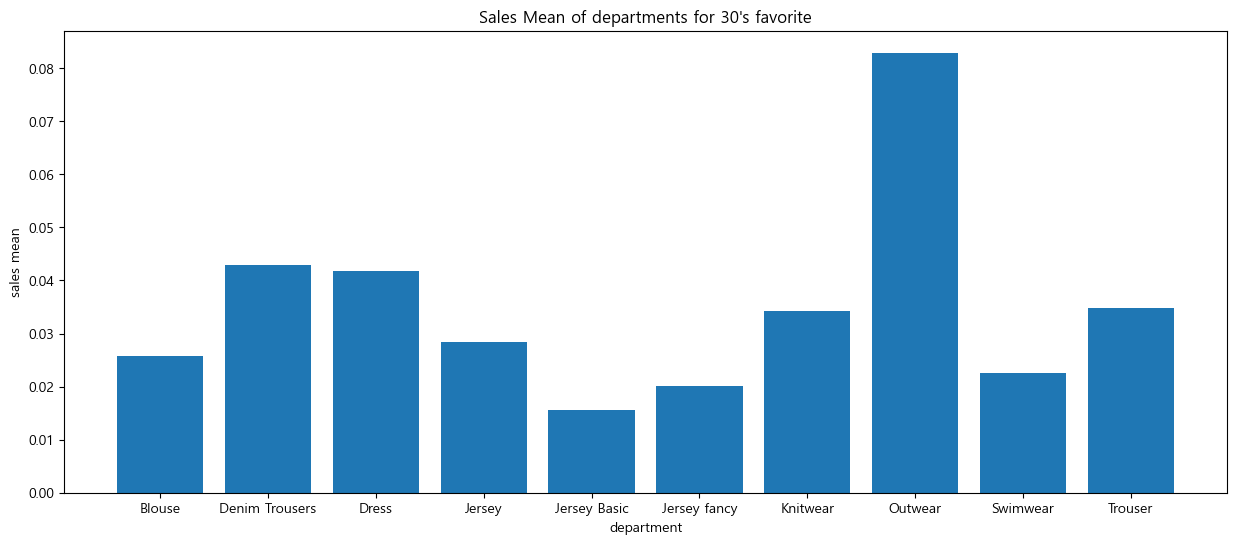

In [107]:
# 30대 매출 상위 10위 소분류의 매출 평균
import matplotlib.pyplot as plt

plt.figure(figsize = (15,6))
plt.bar(de_top_30["department_name"], de_top_30["price"])
plt.xlabel("department")
plt.ylabel("sales mean")
plt.title("Sales Mean of departments for 30's favorite")
plt.show()

In [109]:
# 30대와 50대의 월별 매출 추이
age_30_month = age_30.groupby("t_dat")["price"].sum().reset_index(drop = False)
age_50_month = age_50.groupby("t_dat")["price"].sum().reset_index(drop = False)

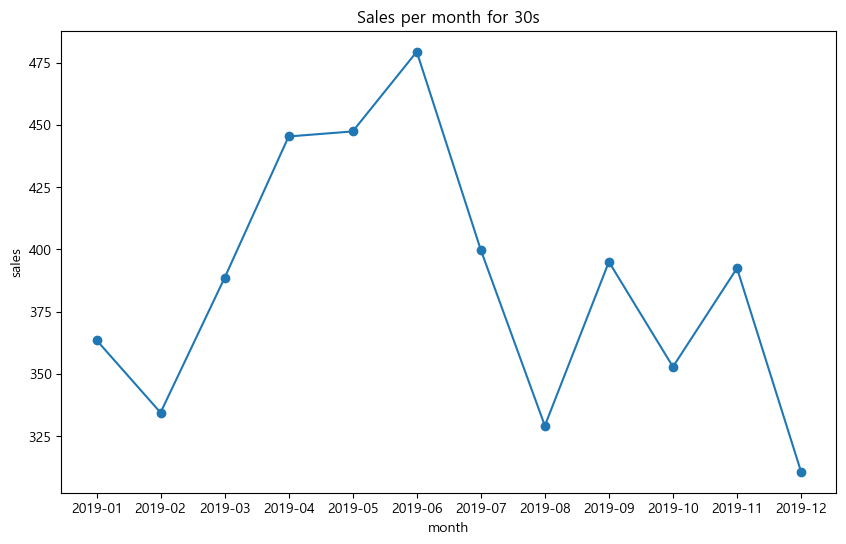

In [111]:
import matplotlib.pyplot as plt

age_30_month["t_dat"] = age_30_month["t_dat"].astype(str)

plt.figure(figsize = (10, 6))
plt.plot(age_30_month["t_dat"], age_30_month["price"], marker = "o")
plt.xlabel("month")
plt.ylabel("sales")
plt.title("Sales per month for 30s")
plt.show()

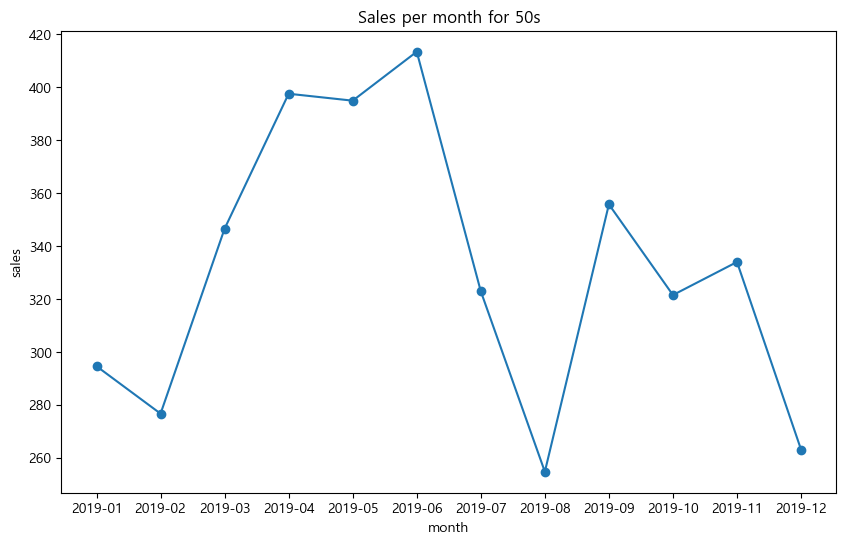

In [113]:
import matplotlib.pyplot as plt

age_50_month["t_dat"] = age_50_month["t_dat"].astype(str)

plt.figure(figsize = (10, 6))
plt.plot(age_50_month["t_dat"], age_50_month["price"], marker = "o")
plt.xlabel("month")
plt.ylabel("sales")
plt.title("Sales per month for 50s")
plt.show()

In [115]:
# 30대와 50대의 옷 그래픽별 매출 
age_30_graph = age_30.groupby("graphical_appearance_name")["price"].sum().reset_index(drop = False)
age_50_graph = age_50.groupby("graphical_appearance_name")["price"].sum().reset_index(drop = False)

In [117]:
# 30대의 옷 그래픽별 매출 Top 10

graph_top10_30 = age_30_graph.sort_values("price", ascending = False)
graph_top10_30 = graph_top10_30[0:10]
graph_top10_30

,graphical_appearance_name,price
24,Solid,2554.161657
0,All over pattern,601.152914
7,Denim,393.972915
14,Melange,275.765983
25,Stripe,197.127152
13,Lace,107.591000
20,Other structure,81.350390
4,Check,75.837356
21,Placement print,39.918169
9,Embroidery,38.190152


In [119]:
# 50대의 옷 그래픽별 매출 Top 10

graph_top10_50 = age_50_graph.sort_values("price", ascending = False)
graph_top10_50 = graph_top10_50[0:10]
graph_top10_50

,graphical_appearance_name,price
24,Solid,2108.752472
0,All over pattern,567.861050
7,Denim,325.994254
14,Melange,266.387847
25,Stripe,183.686220
4,Check,105.947898
13,Lace,66.336661
20,Other structure,59.409915
21,Placement print,43.312034
5,Colour blocking,31.640356


In [121]:
# 30대와 50대의 온/오프라인 구매 건수
age_30_ch = age_30.groupby("sales_channel_id")["sales_channel_id"].count()
age_50_ch = age_50.groupby("sales_channel_id")["sales_channel_id"].count()

age_30_ch = age_30_ch.rename("counts").reset_index(drop = False)
age_50_ch = age_50_ch.rename("counts").reset_index(drop = False)

ch_map = {1 : "Offline", 2: "Online"}

age_30_ch["sales_channel_id"] = age_30_ch["sales_channel_id"].map(ch_map)
age_50_ch["sales_channel_id"] = age_50_ch["sales_channel_id"].map(ch_map)

age_30_ch, age_50_ch

(  sales_channel_id  counts
 0          Offline   41270
 1           Online  124561,
   sales_channel_id  counts
 0          Offline   45912
 1           Online   90378)

In [125]:
# 재구매한 고객 id 리스트 제작
reten_id = (tr_cus_ar["customer_id"].value_counts() > 1)
reten_id = reten_id.reset_index(drop = False)
reten_id = reten_id[reten_id["count"] == True]
reten_id = reten_id["customer_id"].to_list()

In [127]:
# 30대의 고유한 고객 id만 남도록 만든 age_30_id 중 재구매한 고객 id 리스트 안에 있는 것들만 남겨 재구매한 30대 고객 id 수를 구함
age_30_id = age_30.drop_duplicates(subset = ["customer_id"], keep = "first")
age_30_id_re = age_30_id[age_30_id["customer_id"].isin(reten_id)]
age_30_id.shape, age_30_id_re.shape

((66100, 35), (35772, 35))

In [129]:
# 50대의 고유한 고객 id만 남도록 만든 age_50_id 중 재구매한 고객 id 리스트 안에 있는 것들만 남겨 재구매한 50대 고객 id 수를 구함
age_50_id = age_50.drop_duplicates(subset = ["customer_id"], keep = "first")
age_50_id_re = age_50_id[age_50_id["customer_id"].isin(reten_id)]
age_50_id.shape, age_50_id_re.shape

((60761, 35), (29864, 35))

In [131]:
# 30대와 50위의 소분류 매출 상위 10위만 뽑아 두 나이대 데이터를 merge
age_30_depart_top10 = age_30_depart_top10.rename(columns = {"price": "sales by 30"})
age_50_depart_top10 = age_50_depart_top10.rename(columns = {"price": "sales by 50"})

age_3050_depart_top10 = pd.merge(age_30_depart_top10, age_50_depart_top10, on = "department_name", how = "inner")
age_3050_depart_top10

,department_name,sales by 30,sales by 50
0,Knitwear,286.464644,297.501406
1,Trouser,282.433780,328.956220
2,Swimwear,282.042999,225.769304
3,Jersey,279.807745,184.975983
4,Dress,253.380796,246.158033
5,Blouse,209.447542,232.222204
6,Outwear,176.319983,145.968983
7,Denim Trousers,165.143847,124.622305
8,Jersey Basic,134.945677,103.588186
9,Jersey fancy,130.800135,103.420373


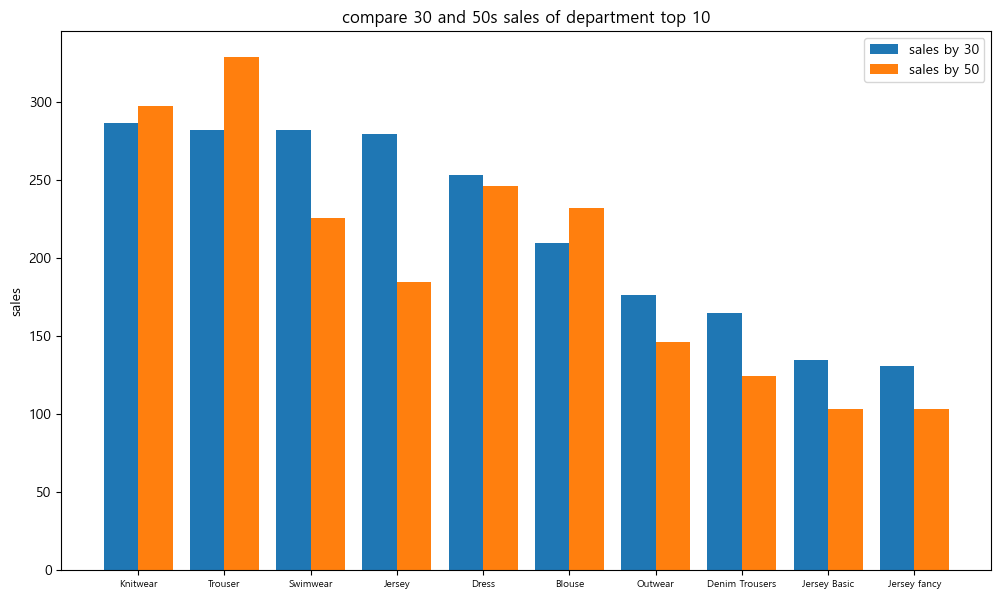

In [133]:
# 둘을 직접 비교하기 위한 subplot
import matplotlib.pyplot as plt
import numpy as np

cats = age_3050_depart_top10["department_name"].to_list()
vals1, vals2 = age_3050_depart_top10["sales by 30"].to_list(), age_3050_depart_top10["sales by 50"].to_list()

w, x = 0.4, np.arange(len(cats))

fig, ax = plt.subplots(figsize = (12, 7))
ax.bar(x - w/2, vals1, width = w, label = "sales by 30")
ax.bar(x + w/2, vals2, width = w, label = "sales by 50")

ax.set_xticks(x)
ax.set_xticklabels(cats, fontdict={"fontsize": 7})
ax.set_ylabel("sales")
ax.set_title("compare 30 and 50s sales of department top 10")
ax.legend()

plt.show()

In [135]:
# 30대와 50대의 소분류 매출 상위 10위의 구매건수 총합 테이블을 만들어서 merge
age_30_de_cnt_10 = age_30_depart_cnt[0:10]
age_50_de_cnt_10 = age_50_depart_cnt[0:10]

age_30_de_cnt_10 = age_30_de_cnt_10.rename(columns = {"article_cnt": "quantity by 30"})
age_50_de_cnt_10 = age_50_de_cnt_10.rename(columns = {"article_cnt": "quantity by 50"})

age_3050_cnt_10 = pd.merge(age_30_de_cnt_10, age_50_de_cnt_10, on = "department_name", how = "inner")
age_3050_cnt_10

,department_name,quantity by 30,quantity by 50
0,Swimwear,12499,9765
1,Jersey,9526,6842
2,Jersey Basic,8625,6484
3,Blouse,8285,8686
4,Trouser,8270,9242
5,Knitwear,8243,8593
6,Jersey fancy,6460,5024
7,Expressive Lingerie,6447,4075
8,Dress,5854,6109
9,Basic 1,5127,3600


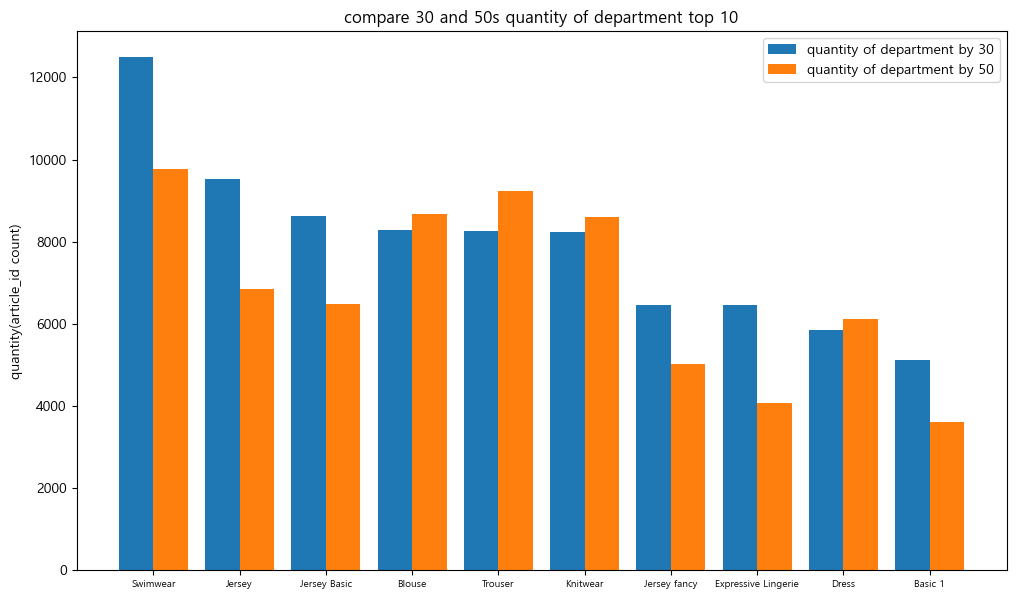

In [137]:
# 둘을 직접 비교하기 위한 subplot
import matplotlib.pyplot as plt
import numpy as np

cats = age_3050_cnt_10["department_name"].to_list()
vals1, vals2 = age_3050_cnt_10["quantity by 30"].to_list(), age_3050_cnt_10["quantity by 50"].to_list()

w, x = 0.4, np.arange(len(cats))

fig, ax = plt.subplots(figsize = (12, 7))
ax.bar(x - w/2, vals1, width = w, label = "quantity of department by 30")
ax.bar(x + w/2, vals2, width = w, label = "quantity of department by 50")

ax.set_xticks(x)
ax.set_xticklabels(cats, fontdict={"fontsize": 7})
ax.set_ylabel("quantity(article_id count)")
ax.set_title("compare 30 and 50s quantity of department top 10")
ax.legend()

plt.show()

<Axes: xlabel='age_group', ylabel='price'>

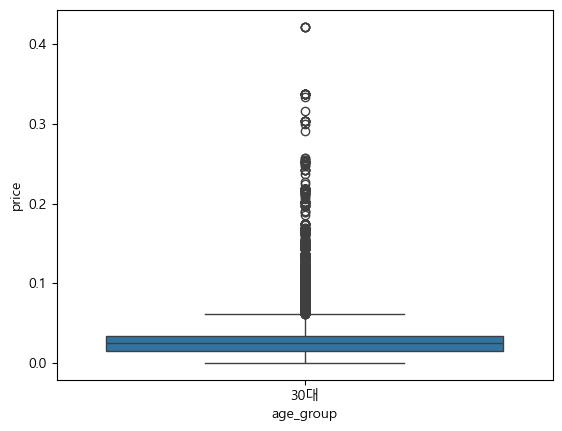

In [139]:
# 30대의 결제 데이터로 그린 결제금액의 분포 box plot
import seaborn as sb
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break

sb.boxplot(data = age_30, x = "age_group", y = "price")

<Axes: xlabel='age_group', ylabel='price'>

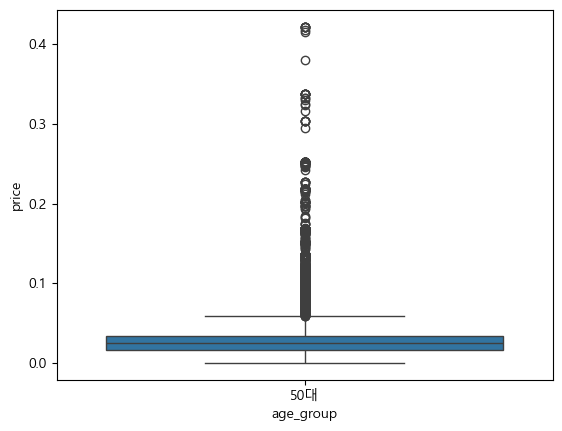

In [145]:
# 50대의 결제 데이터로 그린 결제금액의 분포 box plot
import seaborn as sb
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break

sb.boxplot(data = age_50, x = "age_group", y = "price")

In [148]:
# 두 나이대 그룹을 box plot에 동시에 그리기 위한 30대, 50대 데이터를 가진 age_3050 생성
age_3050 = tr_cus_ar[tr_cus_ar["age_group"].isin(["30대", "50대"])]
age_3050["age_group"].value_counts()

age_group
30대    165831
50대    136290
Name: count, dtype: int64

<Axes: xlabel='age_group', ylabel='price'>

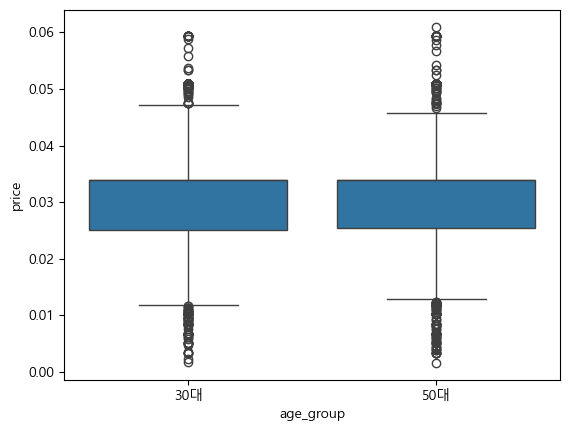

In [150]:
# 두 나이대 그룹의 trousers 결제 금액 분포
import seaborn as sb
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break
trousers_3050 = age_3050[age_3050["department_name"] == "Trousers"]

sb.boxplot(data = trousers_3050, x = "age_group", y = "price")

<Axes: xlabel='age_group', ylabel='price'>

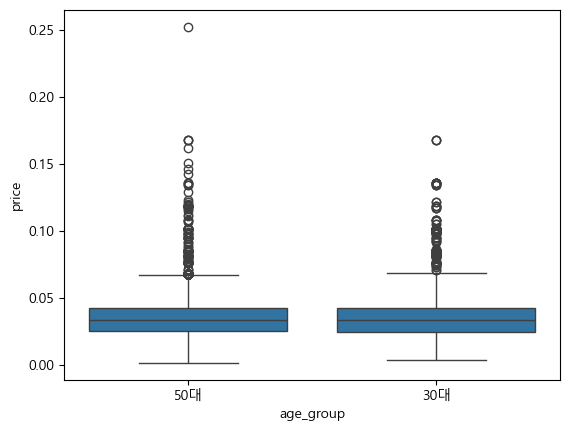

In [151]:
# 두 나이대 그룹의 knitwear 결제 금액 분포
import seaborn as sb
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break
knit_3050 = age_3050[age_3050["department_name"] == "Knitwear"]

sb.boxplot(data = knit_3050, x = "age_group", y = "price")

<Axes: xlabel='age_group', ylabel='price'>

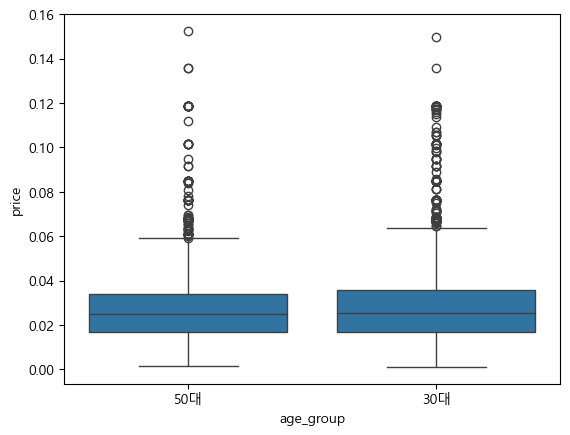

In [153]:
# 두 나이대 그룹의 jersey 결제 금액 분포
import seaborn as sb
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break
jersey_3050 = age_3050[age_3050["department_name"] == "Jersey"]

sb.boxplot(data = jersey_3050, x = "age_group", y = "price")